# Lofted Surface Voronoi Generation

This notebook builds a lofted surface from 8 circles defined by radii in `data/lofted_surface_inputs.json`. Each circle is created on the `XY` plane around the origin and then translated along `Z` in fixed `12` unit increments: `0, 12, 24, ...`.

The loft is sliced by the `YZ` plane through the origin, one side is kept, a padded bounding box is filled with random points from `data/voronoi_points_inputs.json`, a bounded 3D Voronoi diagram is generated, and the cells are intersected with the kept half of the loft. Any later non-uniform scaling uses the center of the initial loft bounding box as its pivot, scales only in `X` and `Y`, and keeps `Z` unchanged.

All intersection curves that hit the kept shape are retained. Closed curves stay closed, and open curves are closed by connecting their endpoints with one straight segment. Only cells with no intersection at all are discarded. The final output is shown as a shaded static render so it remains visible even when notebook widget rendering is unreliable.

In [49]:
import colorsys
import json
from dataclasses import replace
from pathlib import Path

import ipywidgets as widgets
import numpy as np
import pyvista as pv
from IPython.display import Markdown, display

from compass_web.config import (
    MAX_MODEL_SPAN,
    MAX_RADIUS,
    MAX_Z_INCREMENT,
    MIN_RADIUS,
    SMALL_CELL_EXTRUSION_FACTOR,
    PipelineConfig,
    list_saved_configs,
    load_pipeline_config,
    load_pipeline_config_from_saved,
    save_pipeline_config,
    validate_geometry_limits,
)
from compass_web.lofted_surface_voronoi import (
    _build_staged_offset_lofts,
    _fan_surface_from_center,
    _fit_plane,
    _loft_between_polylines,
    _merge_meshes,
    align_neighbouring_polylines,
    analyze_and_generate_surfaces,
    build_analysis_output_meshes,
    build_bounded_voronoi_cells,
    build_lofted_surface,
    build_mesh_printability_report,
    build_polyline_mesh,
    clean_meshes_without_naked_edges,
    clip_surface_in_half,
    close_mesh_boundaries,
    count_connected_regions,
    export_mesh_to_stl,
    extract_naked_edge_loops,
    extract_surface_mesh,
    close_free_vertices,
    find_polyline_neighbours,
    fix_polyline_surface_overlaps,
    intersect_cells_with_surface,
    load_generation_config,
    load_voronoi_point_config,
    _fix_mesh_winding,
    align_loops_and_loft,
    orient_normals_outward,
    point_distance_to_mesh_surface,
    split_and_offset_plane_faces,
    pad_bounds,
    random_points_in_bounds,
    rebuild_polylines_from_discontinuities,
    resolve_non_manifold_faces,
    scale_points_in_xy,
    scale_polydata_in_xy,
    unify_mesh_normals,
    validate_polyline_surfaces,
)
from compass_web.pipeline import (
    build_export_trimesh,
    filter_isolated_polylines,
    run_pipeline,
    run_pipeline_with_retry,
)
from compass_web.smoothing import apply_smoothing_to_config
from compass_web.visualization import (
    camera_position_from_bounds,
    center_from_bounds,
    display_interactive_scene,
    display_static_scene,
    distinct_colors,
    merge_bounds,
    bounds_from_points,
    padded_scene_bounds,
    render_static_scene,
    add_scene_content,
)

pv.set_plot_theme("document")

surface_config_path = Path("data/lofted_surface_inputs.json")
point_config_path = Path("data/voronoi_points_inputs.json")
surface_config = load_generation_config(surface_config_path)
point_config = load_voronoi_point_config(point_config_path)


def make_float_control(
    *,
    value: float,
    min_value: float,
    max_value: float,
    step: float,
    description: str,
    readout_format: str,
    slider_width: str = "440px",
    input_width: str = "100px",
) -> tuple[widgets.HBox, widgets.FloatSlider, widgets.BoundedFloatText]:
    slider = widgets.FloatSlider(
        value=value,
        min=min_value,
        max=max_value,
        step=step,
        description=description,
        continuous_update=False,
        readout=False,
        layout=widgets.Layout(width=slider_width),
        style={"description_width": "70px"},
    )
    text = widgets.BoundedFloatText(
        value=value,
        min=min_value,
        max=max_value,
        step=step,
        layout=widgets.Layout(width=input_width),
    )
    widgets.jslink((slider, "value"), (text, "value"))
    row = widgets.HBox([slider, text])
    return row, slider, text


def make_int_control(
    *,
    value: int,
    min_value: int,
    max_value: int,
    step: int,
    description: str,
    slider_width: str = "440px",
    input_width: str = "100px",
) -> tuple[widgets.HBox, widgets.IntSlider, widgets.BoundedIntText]:
    slider = widgets.IntSlider(
        value=value,
        min=min_value,
        max=max_value,
        step=step,
        description=description,
        continuous_update=False,
        readout=False,
        layout=widgets.Layout(width=slider_width),
        style={"description_width": "70px"},
    )
    text = widgets.BoundedIntText(
        value=value,
        min=min_value,
        max=max_value,
        step=step,
        layout=widgets.Layout(width=input_width),
    )
    widgets.jslink((slider, "value"), (text, "value"))
    row = widgets.HBox([slider, text])
    return row, slider, text


radius_controls = [
    make_float_control(
        value=float(radius),
        min_value=MIN_RADIUS,
        max_value=MAX_RADIUS,
        step=0.001,
        description=f"R{i + 1}",
        readout_format=".3f",
    )
    for i, radius in enumerate(surface_config.radii)
]
radius_rows = [row for row, _, _ in radius_controls]
radius_sliders = [slider for _, slider, _ in radius_controls]

spacing_row, spacing_slider, _ = make_float_control(
    value=float(surface_config.z_increment),
    min_value=4.0,
    max_value=MAX_Z_INCREMENT,
    step=0.01,
    description="Spacing",
    readout_format=".2f",
)
point_count_row, point_count_slider, _ = make_int_control(
    value=int(point_config.seed_count),
    min_value=2,
    max_value=300,
    step=1,
    description="Points",
)
seed_row, seed_slider, _ = make_int_control(
    value=int(point_config.random_seed),
    min_value=0,
    max_value=9999,
    step=1,
    description="Seed",
)
extrusion_row, extrusion_multiplier_slider, _ = make_float_control(
    value=-0.2,
    min_value=-3.0,
    max_value=3.0,
    step=0.05,
    description="Extrude",
    readout_format=".2f",
)
scale_x_row, scale_x_slider, _ = make_float_control(
    value=0.5,
    min_value=0.1,
    max_value=1.5,
    step=0.01,
    description="Scale X",
    readout_format=".2f",
)
scale_y_row, scale_y_slider, _ = make_float_control(
    value=0.5,
    min_value=0.1,
    max_value=1.5,
    step=0.01,
    description="Scale Y",
    readout_format=".2f",
)

_notebook_z_levels: tuple[float, ...] | None = None
_suppress_spacing_z_clear = False


def _on_spacing_slider_changed(_: object = None) -> None:
    global _notebook_z_levels
    if _suppress_spacing_z_clear:
        return
    _notebook_z_levels = None


spacing_slider.observe(_on_spacing_slider_changed, names="value")


configs_dir = Path("configs")
configs_dir.mkdir(exist_ok=True)


def get_pipeline_config() -> PipelineConfig:
    radii = tuple(float(slider.value) for slider in radius_sliders)
    z_increment = float(spacing_slider.value)
    z_levels = _notebook_z_levels
    if z_levels is not None and len(z_levels) != len(radii):
        z_levels = None
    validate_geometry_limits(radii, z_increment, z_levels=z_levels)
    return PipelineConfig(
        radii=radii,
        z_increment=z_increment,
        seed_count=int(point_count_slider.value),
        random_seed=int(seed_slider.value),
        extrusion_multiplier=float(extrusion_multiplier_slider.value),
        scale_x=float(scale_x_slider.value),
        scale_y=float(scale_y_slider.value),
        z_levels=z_levels,
    )


def get_active_surface_config():
    return get_pipeline_config().to_surface_config()


def get_active_point_config():
    return replace(
        point_config,
        seed_count=int(point_count_slider.value),
        random_seed=int(seed_slider.value),
    )


def get_extrusion_multiplier() -> float:
    return float(extrusion_multiplier_slider.value)


def get_planar_scales() -> tuple[float, float]:
    return float(scale_x_slider.value), float(scale_y_slider.value)


display(
    Markdown(
        "### Geometry Controls\n\n"
        "These controls override the JSON defaults for this notebook run only. "
        "Every slider also has a bounded number field on the right so you can click and type exact values.\n\n"
        f"Design guardrails: total width must stay at or below {MAX_MODEL_SPAN:.0f} units and total Z height must also stay at or below {MAX_MODEL_SPAN:.0f} units. "
        "Width here is `2 * max(radius)`, and height is `7 * spacing` because the loft uses 8 circles. "
        "The `Extrude` control can be positive or negative, and the extra `Scale X` and `Scale Y` controls drive the non-uniform deformation applied later around the center of the initial loft bounding box while keeping `Z` unchanged."
    )
)
configs_dir = Path("configs")
configs_dir.mkdir(exist_ok=True)


def _list_saved_configs() -> list[str]:
    return list_saved_configs(configs_dir)


def _save_current_config(_: object = None) -> None:
    cfg = get_pipeline_config()
    saved = save_pipeline_config(cfg, configs_dir)
    if saved is not None:
        config_dropdown.options = ["(current)"] + _list_saved_configs()
        config_status.value = f"<b>Saved: {saved.stem}</b>"
    else:
        config_status.value = "<b>Config identical to existing, not saved.</b>"


def _load_selected_config(_: object = None) -> None:
    global _notebook_z_levels
    name = config_dropdown.value
    if name == "(current)":
        return
    cfg = load_pipeline_config_from_saved(configs_dir / f"{name}.json")
    for i, val in enumerate(cfg.radii):
        if i < len(radius_sliders):
            radius_sliders[i].value = val
    spacing_slider.value = cfg.z_increment
    point_count_slider.value = cfg.seed_count
    seed_slider.value = cfg.random_seed
    extrusion_multiplier_slider.value = cfg.extrusion_multiplier
    scale_x_slider.value = cfg.scale_x
    scale_y_slider.value = cfg.scale_y
    _notebook_z_levels = cfg.z_levels
    config_status.value = f"<b>Loaded: {name}</b>"


config_dropdown = widgets.Dropdown(
    options=["(current)"] + _list_saved_configs(),
    value="(current)",
    description="Config:",
    layout=widgets.Layout(width="300px"),
)
config_save_btn = widgets.Button(description="Save config", button_style="info")
config_load_btn = widgets.Button(description="Load config", button_style="warning")
config_status = widgets.HTML()
config_save_btn.on_click(_save_current_config)
config_load_btn.on_click(_load_selected_config)

display(
    widgets.VBox(
        [
            *radius_rows,
            spacing_row,
            point_count_row,
            seed_row,
            extrusion_row,
            scale_x_row,
            scale_y_row,
            widgets.HBox([config_dropdown, config_load_btn, config_save_btn]),
            config_status,
        ]
    )
)
(surface_config, point_config)


### Geometry Controls

These controls override the JSON defaults for this notebook run only. Every slider also has a bounded number field on the right so you can click and type exact values.

Design guardrails: total width must stay at or below 150 units and total Z height must also stay at or below 150 units. Width here is `2 * max(radius)`, and height is `7 * spacing` because the loft uses 8 circles. The `Extrude` control can be positive or negative, and the extra `Scale X` and `Scale Y` controls drive the non-uniform deformation applied later around the center of the initial loft bounding box while keeping `Z` unchanged.

(LoftedVoronoiConfig(radii=(8.91, 10.446, 10.46, 17.66, 11.26, 19.299, 11.26, 14.46), z_levels=(0.0, 13.38, 26.76, 40.14, 53.52, 66.9, 80.28, 93.66000000000001), z_increment=13.38, circle_resolution=120, slice_normal=(1.0, 0.0, 0.0), slice_origin=(0.0, 0.0, 0.0), bbox_padding=4.0, line_tolerance=0.001),
 VoronoiPointConfig(seed_count=78, random_seed=12))

In [50]:
from dataclasses import replace

from compass_web.lofted_surface_voronoi import build_lofted_surface, clip_surface_in_half
from compass_web.smoothing import (
    HEIGHT_LIMIT_FACTOR,
    MIN_ANGLE_BETWEEN_SEGMENTS_DEG,
    MIN_ANGLE_FROM_VERTICAL_DEG,
    VERTEX_WIDEN_FACTOR,
    apply_smoothing_to_config,
    smooth_radii_and_spacing,
)

display(
    Markdown(
        "### Smoothing shape comparison\\n\\n"
        "Compare **original** widget parameters (no smoothing) with the **rule-corrected** "
        f"geometry (2.5:1 radii, {MIN_ANGLE_FROM_VERTICAL_DEG:.0f} deg / {MIN_ANGLE_BETWEEN_SEGMENTS_DEG:.0f} deg profile, "
        f"height <= {HEIGHT_LIMIT_FACTOR:.0f}x baseline Z). "
        "Shows the lofted surface shape only (no voronoi)."
    )
)

base_cfg = get_pipeline_config()
smoothing_result = smooth_radii_and_spacing(base_cfg.radii, base_cfg.z_increment)

orig_cfg = replace(base_cfg, z_levels=None)
orig_surf_cfg = orig_cfg.to_surface_config()
orig_full = build_lofted_surface(orig_surf_cfg)
orig_half = clip_surface_in_half(orig_full, normal=orig_surf_cfg.slice_normal, origin=orig_surf_cfg.slice_origin)

if smoothing_result.was_adjusted:
    smooth_cfg, _ = apply_smoothing_to_config(base_cfg)
    adj_surf_cfg = smooth_cfg.to_surface_config()
    adj_full = build_lofted_surface(adj_surf_cfg)
    adj_half = clip_surface_in_half(adj_full, normal=adj_surf_cfg.slice_normal, origin=adj_surf_cfg.slice_origin)
else:
    smooth_cfg = orig_cfg
    adj_half = orig_half

all_b = merge_bounds([orig_half.bounds, adj_half.bounds])
scene_b = padded_scene_bounds(all_b, padding_fraction=0.12)
scene_c = center_from_bounds(scene_b)

img_orig = render_static_scene(
    title="Original (widgets, no smoothing)",
    bounds=orig_half.bounds,
    target=orig_half.center,
    meshes=[
        (
            orig_half,
            {"color": "#ff6b6b", "opacity": 1.0, "smooth_shading": True},
        )
    ],
    fit_bounds=scene_b,
    fit_target=scene_c,
    window_size=(560, 420),
)
img_adj = render_static_scene(
    title="All rules applied (smoothed config)",
    bounds=adj_half.bounds,
    target=adj_half.center,
    meshes=[
        (
            adj_half,
            {"color": "#6bff6b", "opacity": 1.0, "smooth_shading": True},
        )
    ],
    fit_bounds=scene_b,
    fit_target=scene_c,
    window_size=(560, 420),
)

display(
    widgets.HBox(
        [
            widgets.Image(value=img_orig, format="png", layout=widgets.Layout(width="500px")),
            widgets.Image(value=img_adj, format="png", layout=widgets.Layout(width="500px")),
        ]
    )
)

if smoothing_result.was_adjusted:
    display(
        Markdown(
            "**Adjustments:**\\n"
            + "\\n".join(f"- {a}" for a in smoothing_result.adjustments)
        )
    )
else:
    display(Markdown("No radii/spacing adjustments were required."))

print("Original radii: ", list(smoothing_result.original_radii))
print("Adjusted radii: ", list(smoothing_result.adjusted_radii))
print("Z levels (adjusted): ", [round(z, 3) for z in smoothing_result.adjusted_z_levels])

smoothing_save_status = widgets.HTML()


def _apply_smoothing_to_sliders(_: object = None) -> None:
    global _notebook_z_levels, _suppress_spacing_z_clear
    if not smoothing_result.was_adjusted:
        smoothing_save_status.value = "<b>No smoothing changes to apply.</b>"
        return
    _suppress_spacing_z_clear = True
    try:
        _notebook_z_levels = tuple(smoothing_result.adjusted_z_levels)
        for i, val in enumerate(smoothing_result.adjusted_radii):
            if i < len(radius_sliders):
                radius_sliders[i].value = float(val)
        spacing_slider.value = float(smoothing_result.adjusted_z_increment)
    finally:
        _suppress_spacing_z_clear = False
    _save_current_config()
    smoothing_save_status.value = "<b>Sliders and Z levels updated; config saved.</b>"


apply_btn = widgets.Button(description="Apply smoothed values & save config", button_style="success")
apply_btn.on_click(_apply_smoothing_to_sliders)
display(widgets.HBox([apply_btn, smoothing_save_status]))


### Smoothing shape comparison\n\nCompare **original** widget parameters (no smoothing) with the **rule-corrected** geometry (2.5:1 radii, 25 deg / 50 deg profile, height <= 2x baseline Z). Shows the lofted surface shape only (no voronoi).

No radii/spacing adjustments were required.

Original radii:  [22.299, 28.505, 23.626, 25.776, 24.681, 18.903, 25.488, 13.616]
Adjusted radii:  [22.299, 28.505, 23.626, 25.776, 24.681, 18.903, 25.488, 13.616]
Z levels (adjusted):  [0.0, 7.03, 14.06, 21.09, 28.12, 35.15, 42.18, 49.21]


In [51]:
# Read the latest widget values once so every downstream cell works from the same inputs.
active_surface_config = get_active_surface_config()
active_point_config = get_active_point_config()
raw_extrusion_multiplier = get_extrusion_multiplier()
extrusion_multiplier = 5.0 * raw_extrusion_multiplier
scale_x, scale_y = get_planar_scales()

# The widest section controls the total width because all circles are centered on the origin.
current_width = 2.0 * max(active_surface_config.radii)
current_height = active_surface_config.z_levels[-1] - active_surface_config.z_levels[0]

# Build the full loft first, then clip it in half along the YZ plane.
full_surface = build_lofted_surface(active_surface_config)
full_loft_bounds = full_surface.bounds
initial_loft_bbox_center = np.array(
    [
        0.5 * (full_loft_bounds[0] + full_loft_bounds[1]),
        0.5 * (full_loft_bounds[2] + full_loft_bounds[3]),
        0.5 * (full_loft_bounds[4] + full_loft_bounds[5]),
    ],
    dtype=float,
)
half_surface = clip_surface_in_half(
    full_surface,
    normal=active_surface_config.slice_normal,
    origin=active_surface_config.slice_origin,
)

# A slightly larger box is used later so the Voronoi cells stay finite before intersection.
padded_bounds = pad_bounds(half_surface.bounds, active_surface_config.bbox_padding)

print(f"Radii: {list(active_surface_config.radii)}")
print(f"Z positions: {list(active_surface_config.z_levels)}")
print(f"Current width: {current_width:.2f} / {MAX_MODEL_SPAN:.0f}")
print(f"Current height: {current_height:.2f} / {MAX_MODEL_SPAN:.0f}")
print(f"Slice plane: YZ at x = {active_surface_config.slice_origin[0]}")
print(f"Voronoi seed points: {active_point_config.seed_count}")
print(f"Voronoi random seed: {active_point_config.random_seed}")
print(f"Extrusion slider value: {raw_extrusion_multiplier:.2f}")
print(f"Effective extrusion multiplier (x5): {extrusion_multiplier:.2f}")
print(f"Planar scaling (X, Y) with Z fixed: ({scale_x:.2f}, {scale_y:.2f})")
print(f"Scaling pivot: {initial_loft_bbox_center.tolist()}")
print(f"Full loft surface: {full_surface.n_points} points / {full_surface.n_cells} cells")
print(f"Kept half surface: {half_surface.n_points} points / {half_surface.n_cells} cells")
print(f"Padded bounds: {padded_bounds}")


Radii: [22.299, 28.505, 23.626, 25.776, 24.681, 18.903, 25.488, 13.616]
Z positions: [0.0, 7.03, 14.06, 21.09, 28.12, 35.15, 42.18, 49.21]
Current width: 57.01 / 150
Current height: 49.21 / 150
Slice plane: YZ at x = 0.0
Voronoi seed points: 160
Voronoi random seed: 4038
Extrusion slider value: -0.03
Effective extrusion multiplier (x5): -0.14
Planar scaling (X, Y) with Z fixed: (0.50, 0.50)
Scaling pivot: [0.0, 0.0, 24.605]
Full loft surface: 960 points / 1680 cells
Kept half surface: 510 points / 868 cells
Padded bounds: (-4.0, 32.504999999999995, -32.504999999999995, 32.504999999999995, -4.0, 53.21)


In [52]:
from compass_web.lofted_surface_voronoi import (
    default_snap_tolerance, compact_polyline_shapes,
    _unique_polyline_points, _find_shared_vertex_pairs,
)

# Fill the padded box with random points. These points are the seeds that define the Voronoi cells.
seed_points = random_points_in_bounds(
    bounds=padded_bounds,
    count=active_point_config.seed_count,
    seed=active_point_config.random_seed,
)

voronoi_cells = build_bounded_voronoi_cells(seed_points, padded_bounds)
tol = active_surface_config.line_tolerance
polyline_snap_tolerance = default_snap_tolerance(tol)

# ── Stage 0: raw intersection ──
raw_closed_polylines = intersect_cells_with_surface(
    surface=half_surface, cells=voronoi_cells, tolerance=tol,
)
stage_0_polylines = [p.copy() for p in raw_closed_polylines]

# ── Stage 1: filter isolated cells ──
closed_polylines, kept_polyline_indices, discarded_polyline_indices = filter_isolated_polylines(
    raw_closed_polylines, tolerance=tol,
)
retained_intersection_polyline_count = len(closed_polylines)
stage_1_polylines = [p.copy() for p in closed_polylines]

# ── Stage 2: compact shapes (remove tails via 2D projection) ──
closed_polylines, compact_removed, compact_msgs = compact_polyline_shapes(
    closed_polylines, tolerance=tol,
)
stage_2_polylines = [p.copy() for p in closed_polylines]

# ── Stage 3: rebuild from discontinuities + cross-polyline intersection snap ──
closed_polylines = rebuild_polylines_from_discontinuities(
    closed_polylines, tolerance=tol,
    discontinuity_angle_degrees=176.0,
    neighbor_snap_tolerance=polyline_snap_tolerance,
)
stage_3_polylines = [p.copy() for p in closed_polylines]

# ── Stage 3b: remove extreme elongated polylines before alignment ──
from compass_web.pipeline import filter_elongated_polylines, ELONGATED_WIDTH_RATIO_THRESHOLD
closed_polylines, elongated_removed, elongated_msgs = filter_elongated_polylines(
    closed_polylines, tolerance=tol,
)
if elongated_removed > 0:
    print(f"Removed {elongated_removed} extreme elongated polyline(s) (WR < {ELONGATED_WIDTH_RATIO_THRESHOLD})")

neighbours_before = find_polyline_neighbours(closed_polylines, tolerance=polyline_snap_tolerance)
edge_pair_count = sum(len(v) for v in neighbours_before.values()) // 2
pre_align_polylines = [p.copy() for p in closed_polylines]

# ── Stage 4: align neighbouring polylines (boundary vertices dampened) ──
closed_polylines = align_neighbouring_polylines(
    closed_polylines, tolerance=tol,
    slice_plane_x=float(active_surface_config.slice_origin[0]),
)
stage_4_polylines = [p.copy() for p in closed_polylines]

max_shift = 0.0
for pre, post in zip(pre_align_polylines, stage_4_polylines):
    n = min(len(pre), len(post))
    if n > 0:
        shift = float(np.max(np.linalg.norm(pre[:n] - post[:n], axis=1)))
        max_shift = max(max_shift, shift)
alignment_changed = max_shift > tol

overlap_report_before = validate_polyline_surfaces(closed_polylines, tolerance=tol)
overlapping_pairs_before = [(a, b, n) for a, b, has, n in overlap_report_before if has]

# ── Stage 5: fix surface overlaps + pocket removal ──
closed_polylines, overlap_relocated, overlap_messages = fix_polyline_surface_overlaps(
    closed_polylines, tolerance=tol,
)
stage_5_polylines = [p.copy() for p in closed_polylines]

overlap_report_after = validate_polyline_surfaces(closed_polylines, tolerance=tol)
overlapping_pairs_after = [(a, b, n) for a, b, has, n in overlap_report_after if has]

# ── Stage 6: close free vertices (snap + absorb + junction insert) ──
closed_polylines, free_snapped, free_msgs = close_free_vertices(
    closed_polylines, half_surface, tolerance=tol,
)
stage_6_polylines = [p.copy() for p in closed_polylines]

# Only the final mesh is needed downstream
polyline_mesh = build_polyline_mesh(closed_polylines)

# ── Collect all stages for the diff viewer ──
pipeline_stages = [
    {
        "name": "Stage 0: Raw intersection",
        "polylines": stage_0_polylines,
        "detail": f"{len(stage_0_polylines)} polylines from cell-surface intersection (unfiltered)",
    },
    {
        "name": "Stage 1: Filter isolated",
        "polylines": stage_1_polylines,
        "detail": (
            f"{len(stage_1_polylines)} kept, {len(discarded_polyline_indices)} isolated cells removed"
        ),
    },
    {
        "name": "Stage 2: Compact shapes",
        "polylines": stage_2_polylines,
        "detail": (
            f"{compact_removed} tail vertices removed by 2D projection analysis"
            + ("; " + "; ".join(compact_msgs) if compact_msgs else "")
        ),
    },
    {
        "name": "Stage 3: Rebuild + snap",
        "polylines": stage_3_polylines,
        "detail": (
            f"{len(stage_3_polylines)} polylines rebuilt from curvature + intersection discontinuities; "
            f"cross-cell vertices within {polyline_snap_tolerance:.4f} snapped"
        ),
    },
    {
        "name": "Stage 4: Align neighbours",
        "polylines": stage_4_polylines,
        "detail": (
            f"Shared-edge sub-paths averaged between neighbours "
            f"(max shift: {max_shift:.4f}, {edge_pair_count} pairs)"
        ),
    },
    {
        "name": "Stage 5: Fix overlaps + pockets",
        "polylines": stage_5_polylines,
        "detail": (
            f"{overlap_relocated} vertices relocated; "
            f"{len(stage_4_polylines) - len(stage_5_polylines)} pockets removed; "
            f"overlaps: {len(overlapping_pairs_before)} -> {len(overlapping_pairs_after)}"
        ),
    },
    {
        "name": "Stage 6: Close free vertices",
        "polylines": stage_6_polylines,
        "detail": "; ".join(free_msgs) if free_msgs else "No free-vertex adjustments needed",
    },
]

print(f"Seed points: {len(seed_points)}, Voronoi cells: {len(voronoi_cells)}")
for s in pipeline_stages:
    print(f"  {s['name']}: {len(s['polylines'])} polylines -- {s['detail']}")
print(f"Final polylines: {len(closed_polylines)}, snap tolerance: {polyline_snap_tolerance:.4f}")


Removed 7 extreme elongated polyline(s) (WR < 0.2)
Seed points: 160, Voronoi cells: 160
  Stage 0: Raw intersection: 107 polylines -- 107 polylines from cell-surface intersection (unfiltered)
  Stage 1: Filter isolated: 100 polylines -- 100 kept, 7 isolated cells removed
  Stage 2: Compact shapes: 100 polylines -- 3 tail vertices removed by 2D projection analysis; Cell 17: removed 1 tail vertex(es) (area: 11.63 -> 10.12); Cell 53: removed 1 tail vertex(es) (area: 0.30 -> 0.21); Cell 67: removed 1 tail vertex(es) (area: 0.24 -> 0.18)
  Stage 3: Rebuild + snap: 100 polylines -- 100 polylines rebuilt from curvature + intersection discontinuities; cross-cell vertices within 0.0200 snapped
  Stage 4: Align neighbours: 93 polylines -- Shared-edge sub-paths averaged between neighbours (max shift: 15.9516, 239 pairs)
  Stage 5: Fix overlaps + pockets: 89 polylines -- 73 vertices relocated; 4 pockets removed; overlaps: 8 -> 1
  Stage 6: Close free vertices: 89 polylines -- Snapped 277 free vert

In [53]:
# ── Step-by-step polyline cleanup diff viewer (interactive 3D) ──
#
# Each pipeline transition opens a native VTK window you can orbit/pan/zoom.
# Before = coral, After = green, Moved vertices = yellow/red spheres.
# A dropdown lets you pick which transition to inspect without re-running.


def _stage_mesh(polylines: list[np.ndarray]) -> pv.PolyData:
    if not polylines:
        return pv.PolyData()
    return build_polyline_mesh(polylines)


def _count_total_unique_verts(polylines: list[np.ndarray]) -> int:
    return sum(len(_unique_polyline_points(p, tol)) for p in polylines)


def _find_moved_vertices(
    before: list[np.ndarray],
    after: list[np.ndarray],
    tolerance: float,
) -> tuple[np.ndarray, np.ndarray, int]:
    """Find vertices that moved, appeared, or disappeared between two stages."""
    moved_before: list[np.ndarray] = []
    moved_after: list[np.ndarray] = []
    n_common = min(len(before), len(after))
    for i in range(n_common):
        ub = _unique_polyline_points(before[i], tolerance)
        ua = _unique_polyline_points(after[i], tolerance)
        n = min(len(ub), len(ua))
        if n > 0:
            diffs = np.linalg.norm(ub[:n] - ua[:n], axis=1)
            mask = diffs > tolerance
            if np.any(mask):
                moved_before.extend(ub[:n][mask])
                moved_after.extend(ua[:n][mask])
        if len(ub) > n:
            moved_before.extend(ub[n:])
        if len(ua) > n:
            moved_after.extend(ua[n:])
    for i in range(n_common, len(before)):
        moved_before.extend(_unique_polyline_points(before[i], tolerance))
    for i in range(n_common, len(after)):
        moved_after.extend(_unique_polyline_points(after[i], tolerance))
    mb = np.array(moved_before, dtype=float) if moved_before else np.zeros((0, 3))
    ma = np.array(moved_after, dtype=float) if moved_after else np.zeros((0, 3))
    return mb, ma, max(len(moved_before), len(moved_after))


def _open_transition_viewer(
    title: str,
    detail: str,
    mesh_before: pv.PolyData,
    mesh_after: pv.PolyData,
    moved_before: np.ndarray,
    moved_after: np.ndarray,
) -> None:
    """Open a native VTK window showing the before/after overlay."""
    cam_bounds = padded_scene_bounds(half_surface.bounds, padding_fraction=0.12)
    cam_target = center_from_bounds(cam_bounds)
    cam_pos = camera_position_from_bounds(cam_bounds, cam_target)

    pl = pv.Plotter(notebook=False, window_size=(1500, 950))
    pl.set_background("#1a1a2e")
    pl.add_mesh(half_surface, color="#444466", opacity=0.10, smooth_shading=True)
    if mesh_before.n_cells > 0:
        pl.add_mesh(mesh_before, color="#ff6644", line_width=2,
                     render_lines_as_tubes=True, opacity=0.45, label="Before")
    if mesh_after.n_cells > 0:
        pl.add_mesh(mesh_after, color="#44ff88", line_width=3,
                     render_lines_as_tubes=True, label="After")
    if len(moved_before) > 0:
        pl.add_points(moved_before, color="#ff4444", point_size=9,
                       render_points_as_spheres=True, label="Moved (old pos)")
    if len(moved_after) > 0:
        pl.add_points(moved_after, color="#ffee44", point_size=9,
                       render_points_as_spheres=True, label="Moved (new pos)")
    pl.add_legend(bcolor=(0.1, 0.1, 0.2, 0.8), face=None)
    pl.add_text(title, position="upper_left", font_size=13, color="white")
    pl.add_text(detail, position="lower_left", font_size=9, color="#bbbbbb")
    pl.add_axes()
    pl.camera_position = cam_pos
    pl.show()


# Pre-compute meshes and diffs for every stage and transition
_stage_data: list[dict] = []
for si, stage in enumerate(pipeline_stages):
    _stage_data.append({
        "mesh": _stage_mesh(stage["polylines"]),
        "verts": _count_total_unique_verts(stage["polylines"]),
    })

_transitions: list[dict] = []
for si in range(1, len(pipeline_stages)):
    prev = pipeline_stages[si - 1]
    curr = pipeline_stages[si]
    mb, ma, n_moved = _find_moved_vertices(prev["polylines"], curr["polylines"], tol)
    _transitions.append({
        "prev_idx": si - 1, "curr_idx": si,
        "moved_before": mb, "moved_after": ma, "n_moved": n_moved,
    })

# Build detail strings
_transition_details: list[str] = []
_transition_labels: list[str] = []
for tr in _transitions:
    sp = pipeline_stages[tr["prev_idx"]]
    sc = pipeline_stages[tr["curr_idx"]]
    dp, dc = _stage_data[tr["prev_idx"]], _stage_data[tr["curr_idx"]]
    detail = (
        f"Polylines: {len(sp['polylines'])} -> {len(sc['polylines'])}  |  "
        f"Vertices: {dp['verts']} -> {dc['verts']}  |  "
        f"Changed: {tr['n_moved']}  |  {sc['detail']}"
    )
    label = f"{tr['prev_idx']}->{tr['curr_idx']}: {sp['name']}  ->  {sc['name']}"
    _transition_details.append(detail)
    _transition_labels.append(label)

# Print text summary
display(Markdown(
    "## Polyline Cleanup Pipeline — Interactive Diff Viewer\n\n"
    "Use the dropdown to pick a transition, then click **Open 3D** to launch a "
    "native rotatable window.  \n"
    "**Coral** = before, **Green** = after, **Yellow dots** = moved/added vertices, "
    "**Red dots** = removed/old positions."
))
for i, (lbl, det) in enumerate(zip(_transition_labels, _transition_details)):
    print(f"  {lbl}")
    print(f"    {det}")

# Dropdown + button UI
_dd = widgets.Dropdown(
    options=[(lbl, i) for i, lbl in enumerate(_transition_labels)],
    value=0,
    description="Transition:",
    style={"description_width": "90px"},
    layout=widgets.Layout(width="650px"),
)
_detail_html = widgets.HTML(value=f"<small>{_transition_details[0]}</small>")

def _on_dd_change(change):
    _detail_html.value = f"<small>{_transition_details[change['new']]}</small>"
_dd.observe(_on_dd_change, names="value")

_open_btn = widgets.Button(
    description="Open 3D Viewer",
    button_style="info",
    layout=widgets.Layout(width="180px"),
)

def _on_open(_event):
    ti = _dd.value
    tr = _transitions[ti]
    _open_transition_viewer(
        title=_transition_labels[ti],
        detail=_transition_details[ti],
        mesh_before=_stage_data[tr["prev_idx"]]["mesh"],
        mesh_after=_stage_data[tr["curr_idx"]]["mesh"],
        moved_before=tr["moved_before"],
        moved_after=tr["moved_after"],
    )
_open_btn.on_click(_on_open)

_open_all_btn = widgets.Button(
    description="Open ALL transitions",
    button_style="warning",
    layout=widgets.Layout(width="200px"),
)

def _on_open_all(_event):
    for ti in range(len(_transitions)):
        tr = _transitions[ti]
        _open_transition_viewer(
            title=_transition_labels[ti],
            detail=_transition_details[ti],
            mesh_before=_stage_data[tr["prev_idx"]]["mesh"],
            mesh_after=_stage_data[tr["curr_idx"]]["mesh"],
            moved_before=tr["moved_before"],
            moved_after=tr["moved_after"],
        )
_open_all_btn.on_click(_on_open_all)

display(widgets.VBox([
    widgets.HBox([_dd, _open_btn, _open_all_btn]),
    _detail_html,
]))

display(Markdown(
    f"---\n**Final result** used by all downstream cells: "
    f"**{len(closed_polylines)} polylines** with "
    f"**{_count_total_unique_verts(closed_polylines)} unique vertices**."
))

## Polyline Cleanup Pipeline — Interactive Diff Viewer

Use the dropdown to pick a transition, then click **Open 3D** to launch a native rotatable window.  
**Coral** = before, **Green** = after, **Yellow dots** = moved/added vertices, **Red dots** = removed/old positions.

  0->1: Stage 0: Raw intersection  ->  Stage 1: Filter isolated
    Polylines: 107 -> 100  |  Vertices: 3937 -> 3876  |  Changed: 61  |  100 kept, 7 isolated cells removed
  1->2: Stage 1: Filter isolated  ->  Stage 2: Compact shapes
    Polylines: 100 -> 100  |  Vertices: 3876 -> 3873  |  Changed: 26  |  3 tail vertices removed by 2D projection analysis; Cell 17: removed 1 tail vertex(es) (area: 11.63 -> 10.12); Cell 53: removed 1 tail vertex(es) (area: 0.30 -> 0.21); Cell 67: removed 1 tail vertex(es) (area: 0.24 -> 0.18)
  2->3: Stage 2: Compact shapes  ->  Stage 3: Rebuild + snap
    Polylines: 100 -> 100  |  Vertices: 3873 -> 1640  |  Changed: 3684  |  100 polylines rebuilt from curvature + intersection discontinuities; cross-cell vertices within 0.0200 snapped
  3->4: Stage 3: Rebuild + snap  ->  Stage 4: Align neighbours
    Polylines: 100 -> 93  |  Vertices: 1640 -> 1636  |  Changed: 1469  |  Shared-edge sub-paths averaged between neighbours (max shift: 15.9516, 239 pairs)
  4-

---
**Final result** used by all downstream cells: **89 polylines** with **2153 unique vertices**.

In [54]:
# Analyze each retained curve and generate the derived surface patches.
curve_result = analyze_and_generate_surfaces(
    closed_polylines,
    loft_bounds=full_surface.bounds,
    tolerance=active_surface_config.line_tolerance,
    extrusion_multiplier=extrusion_multiplier,
    small_cell_extrusion_factor=SMALL_CELL_EXTRUSION_FACTOR,
    extrusion_scale_origin=initial_loft_bbox_center,
    planar_scale_factors=(scale_x, scale_y),
    slice_plane_x=active_surface_config.slice_origin[0],
)
analysis_original_polylines = [analysis.original_polyline for analysis in curve_result.analyses]
analysis_followup_polylines = [analysis.followup_polyline for analysis in curve_result.analyses]
followup_polyline_mesh = build_polyline_mesh(list(curve_result.followup_polylines))
bbox_edge_meshes = [analysis.bbox_mesh.extract_all_edges() for analysis in curve_result.analyses]
circle_centers = np.array([analysis.circle_center for analysis in curve_result.analyses], dtype=float)
scaled_circle_centers = np.array([analysis.scaled_circle_center for analysis in curve_result.analyses], dtype=float)
extrusion_base_vectors = np.array([analysis.extrusion_base_vector for analysis in curve_result.analyses], dtype=float)
extrusion_base_lengths = np.linalg.norm(extrusion_base_vectors, axis=1) if len(curve_result.analyses) > 0 else np.zeros(0, dtype=float)
curve_lengths = np.array([analysis.curve_length for analysis in curve_result.analyses], dtype=float)
bbox_volumes = np.array([analysis.bbox_volume for analysis in curve_result.analyses], dtype=float)
ratios = np.array([analysis.ratio for analysis in curve_result.analyses], dtype=float)
sorted_indices = np.argsort(ratios)[::-1]
large_curve_count = sum(analysis.ratio >= curve_result.average_ratio for analysis in curve_result.analyses)
small_curve_count = len(curve_result.analyses) - large_curve_count
discontinuity_point_sets = [analysis.discontinuity_points for analysis in curve_result.analyses]
all_discontinuity_points = (
    np.vstack([points for points in discontinuity_point_sets if len(points) > 0])
    if any(len(points) > 0 for points in discontinuity_point_sets)
    else np.zeros((0, 3), dtype=float)
)
curve_colors = [
    "#%02x%02x%02x" % tuple(int(channel * 255) for channel in colorsys.hsv_to_rgb(index / len(curve_result.analyses), 0.7, 1.0))
    for index in range(len(curve_result.analyses))
] if curve_result.analyses else []
curve_label_points = np.array([
    analysis.followup_polyline[:-1].mean(axis=0) for analysis in curve_result.analyses
], dtype=float) if curve_result.analyses else np.zeros((0, 3), dtype=float)
curve_labels = [f"crv {index + 1}" for index in range(len(curve_result.analyses))]
analysis_output_result = build_analysis_output_meshes(
    curve_result.analyses,
    average_ratio=curve_result.average_ratio,
    loft_bounds=full_surface.bounds,
    tolerance=active_surface_config.line_tolerance,
    extrusion_multiplier=extrusion_multiplier,
    small_cell_extrusion_factor=SMALL_CELL_EXTRUSION_FACTOR,
    slice_plane_x=active_surface_config.slice_origin[0],
)
analysis_preview_output_meshes = list(analysis_output_result.preview_meshes)
analysis_output_meshes = list(analysis_output_result.output_meshes)
analysis_output_modes = list(analysis_output_result.output_modes)
removed_by_retained_volume_indices = list(analysis_output_result.removed_by_retained_volume_indices)

mesh_cleanup = clean_meshes_without_naked_edges(
    analysis_output_meshes,
    tolerance=active_surface_config.line_tolerance,
)
merge_ready_output_meshes = list(mesh_cleanup.kept_meshes)
merge_ready_output_surfaces = list(mesh_cleanup.kept_surface_meshes)
removed_output_mesh_indices = list(mesh_cleanup.removed_indices)
generated_surface = _merge_meshes(merge_ready_output_meshes) if merge_ready_output_meshes else half_surface
generated_bounds = generated_surface.bounds if generated_surface.n_points else half_surface.bounds
generated_target = generated_surface.center if generated_surface.n_points else half_surface.center

print(f"Analyzed curves: {len(curve_result.analyses)}")
print(f"Average volume/length ratio: {curve_result.average_ratio:.4f}")
print(f"Extrusion multiplier used: {extrusion_multiplier:.2f}")
print(f"Small-cell extrusion factor: {SMALL_CELL_EXTRUSION_FACTOR:.2f}")
print(f"Scaled-center extrusion pivot: {initial_loft_bbox_center.tolist()}")
print(f"Planar scaling used for center vectors (X, Y) with Z fixed: ({scale_x:.2f}, {scale_y:.2f})")
print(f"Curves classified as large: {large_curve_count}")
print(f"Curves classified as small: {small_curve_count}")
print(f"Generated surface faces after retained-volume filtering and naked-edge cleanup: {generated_surface.n_cells}")
print(f"Cells removed by retained-volume criterion: {len(removed_by_retained_volume_indices)}")
print(f"Cells kept for downstream merge: {len(merge_ready_output_meshes)}")
print(f"Cells removed because they have no naked edges: {len(removed_output_mesh_indices)}")
print(f"Large-curve loft faces: {sum(mesh.n_cells for mesh, mode in zip(analysis_output_meshes, analysis_output_modes, strict=True) if mode == 'large')}")
print(f"Small-curve fan faces after retained-volume criterion: {sum(mesh.n_cells for mesh, mode in zip(analysis_output_meshes, analysis_output_modes, strict=True) if mode == 'small')}")
if len(extrusion_base_lengths) > 0:
    print(
        f"Scaled-center vector lengths - min: {extrusion_base_lengths.min():.3f}, "
        f"max: {extrusion_base_lengths.max():.3f}, "
        f"mean: {extrusion_base_lengths.mean():.3f}"
    )
if curve_result.followup_polylines:
    print(
        f"Working polyline segments - min: {min(len(polyline) - 1 for polyline in curve_result.followup_polylines)}, "
        f"max: {max(len(polyline) - 1 for polyline in curve_result.followup_polylines)}, "
        f"mean: {np.mean([len(polyline) - 1 for polyline in curve_result.followup_polylines]):.1f}"
    )
else:
    print("Working polyline segments: no retained curves were generated.")
print(f"Discontinuity markers total: {len(all_discontinuity_points)}")

top_count = min(8, len(sorted_indices))
summary_rows = [
    (
        int(index),
        float(ratios[index]),
        float(bbox_volumes[index]),
        float(curve_lengths[index]),
    )
    for index in sorted_indices[:top_count]
]
summary_rows


Analyzed curves: 89
Average volume/length ratio: 4.2175
Extrusion multiplier used: -0.14
Small-cell extrusion factor: 0.10
Scaled-center extrusion pivot: [0.0, 0.0, 24.605]
Planar scaling used for center vectors (X, Y) with Z fixed: (0.50, 0.50)
Curves classified as large: 28
Curves classified as small: 61
Generated surface faces after retained-volume filtering and naked-edge cleanup: 5111
Cells removed by retained-volume criterion: 0
Cells kept for downstream merge: 89
Cells removed because they have no naked edges: 0
Large-curve loft faces: 3944
Small-curve fan faces after retained-volume criterion: 1167
Scaled-center vector lengths - min: 6.927, max: 13.659, mean: 11.460
Working polyline segments - min: 5, max: 54, mean: 24.2
Discontinuity markers total: 2153


[(85, 24.187687977306314, 1127.454065001235, 46.612725699911856),
 (34, 21.4223992111124, 1105.942590331307, 51.62552426703091),
 (31, 18.488717706056256, 1027.4999547366037, 55.5744303673386),
 (27, 16.915363820604295, 814.0700961707605, 48.12607667233008),
 (72, 15.669705307134318, 707.2742838000036, 45.13641258320193),
 (69, 13.87572177383636, 633.2186416311289, 45.635005656073815),
 (70, 13.65039110988243, 681.6801695801877, 49.93850828835768),
 (4, 13.13599742254936, 753.2740879392107, 57.344262769581114)]

In [55]:
def show_step(title: str, explanation: str) -> None:
    display(Markdown(f"### {title}\n\n{explanation}"))


def selected_curve_indices(curve_index: int, curve_count: int, show_all_up_to: bool) -> list[int]:
    if curve_index <= 0:
        return []
    if show_all_up_to:
        return list(range(min(curve_index, curve_count)))
    return [min(curve_index, curve_count) - 1]


def build_selected_discontinuity_points(indices: list[int]) -> np.ndarray:
    selected_sets = [discontinuity_point_sets[index] for index in indices if len(discontinuity_point_sets[index]) > 0]
    if not selected_sets:
        return np.zeros((0, 3), dtype=float)
    return np.vstack(selected_sets)


def build_selected_centers(indices: list[int]) -> np.ndarray:
    if not indices:
        return np.zeros((0, 3), dtype=float)
    return circle_centers[indices]


def build_selected_curve_label_points(indices: list[int]) -> np.ndarray:
    if not indices:
        return np.zeros((0, 3), dtype=float)
    return curve_label_points[indices]


def build_selected_curve_labels(indices: list[int]) -> list[str]:
    return [curve_labels[index] for index in indices]


def build_selected_curve_layers(indices: list[int]) -> list[tuple[pv.PolyData, dict[str, object]]]:
    return [
        (
            build_polyline_mesh([analysis_followup_polylines[index]]),
            {
                "color": curve_colors[index],
                "line_width": 3,
                "opacity": 1.0,
            },
        )
        for index in indices
    ]


def build_selected_output_layers(indices: list[int]) -> list[tuple[pv.PolyData, dict[str, object]]]:
    return [
        (
            analysis_preview_output_meshes[index],
            {
                "color": curve_colors[index],
                "opacity": 1.0,
                "smooth_shading": True,
            },
        )
        for index in indices
        if analysis_preview_output_meshes[index].n_points > 0
    ]


def selected_curve_view_fit(indices: list[int]) -> tuple[tuple[float, float, float, float, float, float], np.ndarray]:
    if not indices:
        return padded_scene_bounds(half_surface.bounds, padding_fraction=0.08), np.asarray(half_surface.center, dtype=float)
    fit_bounds_list = [
        build_polyline_mesh([analysis_followup_polylines[index]]).bounds
        for index in indices
        if len(analysis_followup_polylines[index]) > 0
    ]
    point_bounds = bounds_from_points(build_selected_discontinuity_points(indices))
    label_bounds = bounds_from_points(build_selected_curve_label_points(indices))
    if point_bounds is not None:
        fit_bounds_list.append(point_bounds)
    if label_bounds is not None:
        fit_bounds_list.append(label_bounds)
    merged = merge_bounds(fit_bounds_list) if fit_bounds_list else half_surface.bounds
    padded = padded_scene_bounds(merged, padding_fraction=0.3, min_padding=1.5)
    return padded, center_from_bounds(padded)


def selected_output_view_fit(indices: list[int], show_final: bool) -> tuple[tuple[float, float, float, float, float, float], np.ndarray]:
    if not indices:
        return padded_scene_bounds(generated_bounds, padding_fraction=0.08), np.asarray(generated_target, dtype=float)
    selected_meshes = (
        [analysis_output_meshes[index] for index in indices if analysis_output_meshes[index].n_points > 0]
        if show_final
        else [analysis_preview_output_meshes[index] for index in indices if analysis_preview_output_meshes[index].n_points > 0]
    )
    fit_bounds_list = [mesh.bounds for mesh in selected_meshes]
    center_bounds = bounds_from_points(build_selected_centers(indices))
    label_bounds = bounds_from_points(build_selected_centers(indices))
    if center_bounds is not None:
        fit_bounds_list.append(center_bounds)
    if label_bounds is not None:
        fit_bounds_list.append(label_bounds)
    merged = merge_bounds(fit_bounds_list) if fit_bounds_list else generated_bounds
    padded = padded_scene_bounds(merged, padding_fraction=0.32, min_padding=1.5)
    return padded, center_from_bounds(padded)


def make_curve_subset_browser() -> None:
    curve_row, slider, _ = make_int_control(
        value=0,
        min_value=0,
        max_value=len(analysis_followup_polylines),
        step=1,
        description="Curve",
        slider_width="320px",
        input_width="90px",
    )
    show_all_checkbox = widgets.Checkbox(
        value=True,
        description="Show all from 0 to selected curve",
    )
    show_final_checkbox = widgets.Checkbox(
        value=False,
        description="Show generated output surfaces",
    )
    summary = widgets.HTML()
    details = widgets.HTML(layout=widgets.Layout(max_height="180px", overflow="auto"))
    curves_image = widgets.Image(format="png", layout=widgets.Layout(width="540px"))
    outputs_image = widgets.Image(format="png", layout=widgets.Layout(width="540px"))

    def update_view(_: object | None = None) -> None:
        indices = selected_curve_indices(slider.value, len(analysis_followup_polylines), show_all_checkbox.value)
        selected_points = build_selected_discontinuity_points(indices)
        selected_centers = build_selected_centers(indices)
        selected_label_points = build_selected_curve_label_points(indices)
        selected_labels = build_selected_curve_labels(indices)
        selected_modes = [analysis_output_modes[index] for index in indices]
        output_title = "Generated output surfaces for the selected curves" if show_final_checkbox.value else "Preview loft bands for the selected curves"
        curve_layers = build_selected_curve_layers(indices)
        preview_output_layers = build_selected_output_layers(indices)
        final_output_layers = [
            (
                analysis_output_meshes[index],
                {
                    "color": curve_colors[index],
                    "opacity": 1.0,
                    "smooth_shading": True,
                },
            )
            for index in indices
            if analysis_output_meshes[index].n_points > 0
        ]
        curve_fit_bounds, curve_fit_target = selected_curve_view_fit(indices)
        output_fit_bounds, output_fit_target = selected_output_view_fit(indices, show_final_checkbox.value)
        summary.value = (
            f"<b>Selected curves:</b> {len(indices)}"
            f" | <b>Large outputs:</b> {sum(mode == 'large' for mode in selected_modes)}"
            f" | <b>Small outputs:</b> {sum(mode == 'small' for mode in selected_modes)}"
            f" | <b>Output mode:</b> {'generated output' if show_final_checkbox.value else 'preview loft bands'}"
            " | <b>Curve 0</b> means hide all curves and generated outputs."
        )
        if indices:
            detail_rows = [
                f"<li><b>{curve_labels[index]}</b> | class: {analysis_output_modes[index]} | ratio: {ratios[index]:.2f} | length: {curve_lengths[index]:.2f} | discontinuities: {len(discontinuity_point_sets[index])}</li>"
                for index in indices
            ]
            details.value = "<b>Selected curve info</b><ul>" + "".join(detail_rows) + "</ul>"
        else:
            details.value = "<b>Selected curve info</b><div>No curve selected.</div>"
        curves_image.value = render_static_scene(
            title="Selected retained curves and discontinuity markers",
            bounds=half_surface.bounds,
            target=half_surface.center,
            meshes=[
                (
                    half_surface,
                    {
                        "color": "#727272",
                        "opacity": 0.12,
                        "smooth_shading": True,
                    },
                ),
            ],
            line_meshes=curve_layers,
            point_sets=[
                (
                    selected_points,
                    {
                        "color": "#ff4d4d",
                        "point_size": 13,
                        "render_points_as_spheres": True,
                        "opacity": 1.0,
                    },
                ),
            ],
            label_sets=[
                (
                    selected_label_points,
                    selected_labels,
                    {
                        "shape_opacity": 0.2,
                        "fill_shape": True,
                        "font_size": 16,
                        "text_color": "white",
                        "point_color": "#ffe082",
                        "margin": 4,
                        "show_points": False,
                        "always_visible": True,
                    },
                ),
            ],
            fit_bounds=curve_fit_bounds,
            fit_target=curve_fit_target,
            zoom_factor=1.18,
            window_size=(1000, 760),
        )
        outputs_image.value = render_static_scene(
            title=output_title,
            bounds=generated_bounds,
            target=generated_target,
            meshes=[
                (
                    half_surface,
                    {
                        "color": "#808080",
                        "opacity": 0.08,
                        "smooth_shading": True,
                    },
                ),
                *(preview_output_layers if not show_final_checkbox.value else final_output_layers),
            ],
            point_sets=[
                (
                    selected_centers,
                    {
                        "color": "#ffe082",
                        "point_size": 12,
                        "render_points_as_spheres": True,
                        "opacity": 1.0,
                    },
                ),
            ],
            label_sets=[
                (
                    selected_centers,
                    selected_labels,
                    {
                        "shape_opacity": 0.2,
                        "fill_shape": True,
                        "font_size": 16,
                        "text_color": "white",
                        "point_color": "#ffe082",
                        "margin": 4,
                        "show_points": False,
                        "always_visible": True,
                    },
                ),
            ],
            fit_bounds=output_fit_bounds,
            fit_target=output_fit_target,
            zoom_factor=1.18,
            window_size=(1000, 760),
        )

    slider.observe(update_view, names="value")
    show_all_checkbox.observe(update_view, names="value")
    show_final_checkbox.observe(update_view, names="value")
    update_view()

    display(
        widgets.VBox(
            [
                curve_row,
                widgets.HBox([show_all_checkbox, show_final_checkbox]),
                summary,
                widgets.HBox([curves_image, outputs_image]),
                details,
            ]
        )
    )


## Geometry Walkthrough

This section keeps the workflow visual and beginner-friendly. The controls at the top now let you either drag or type exact values for the radii, circle spacing, Voronoi point count, Voronoi seed, extrusion multiplier, and the two planar scaling values for `X` and `Y` before rerunning the downstream cells.

1. Build the loft from the 8 circle sections and clip it with the `YZ` plane so the workflow operates on only one side of the shape.
2. Expand that kept half with a padded bounding box and place random seed points inside it so every Voronoi region becomes bounded instead of shooting off to infinity.
3. Filter out isolated intersection cells that share no direct boundary points with other cells, then show the retained intersection curves with one color per curve.
4. Use the curve browser to reveal either one selected curve or all curves up to the selected index, together with their corresponding generated outputs. The red markers are detected from tangent breaks together with curvature-transition boundaries, not just obvious kinks.
5. Show the generated open surface patches exactly as they come out of the curved-loop follow-up stage, now using extrusion vectors built from each original fitted-circle center to its non-uniformly scaled counterpart.
6. In a new code cell, merge all of those open patches into one larger open geometry while keeping the holes and open boundaries intact.
7. In the next code cell, create a second unit by applying the same non-uniform `X/Y` scale to that merged open geometry around the center of the initial loft bounding box while keeping `Z` unchanged.
8. In another code cell, extract and visualize the naked edges of both open units so it is easy to confirm whether the boundaries are only the exterior loops and holes.
9. Loft between the corresponding naked-edge loops and merge those loft bands with the two open units, then check whether any naked edges remain.
10. Use the interactive 3D view to orbit, pan, and zoom around the assembled result.
11. Export the final assembled geometry to STL.

The size guardrails stay explicit throughout the notebook: total width is `2 * max(radius)` and total height is `7 * spacing`, and both must stay at or below `150` units. The reason for this step-by-step layout is that each later result depends on geometry extracted from the previous one, so seeing the intermediate state makes it much easier to understand why the final surfaces look the way they do.


### Step 1: Loft the circles and clip the shape in half

The eight circular sections are connected into one lofted skin. The blue plane is the YZ slicing plane at x = 0, and the solid orange surface is the kept half. This clip removes the mirrored side so the later Voronoi intersections are easier to interpret and do not duplicate across both halves.

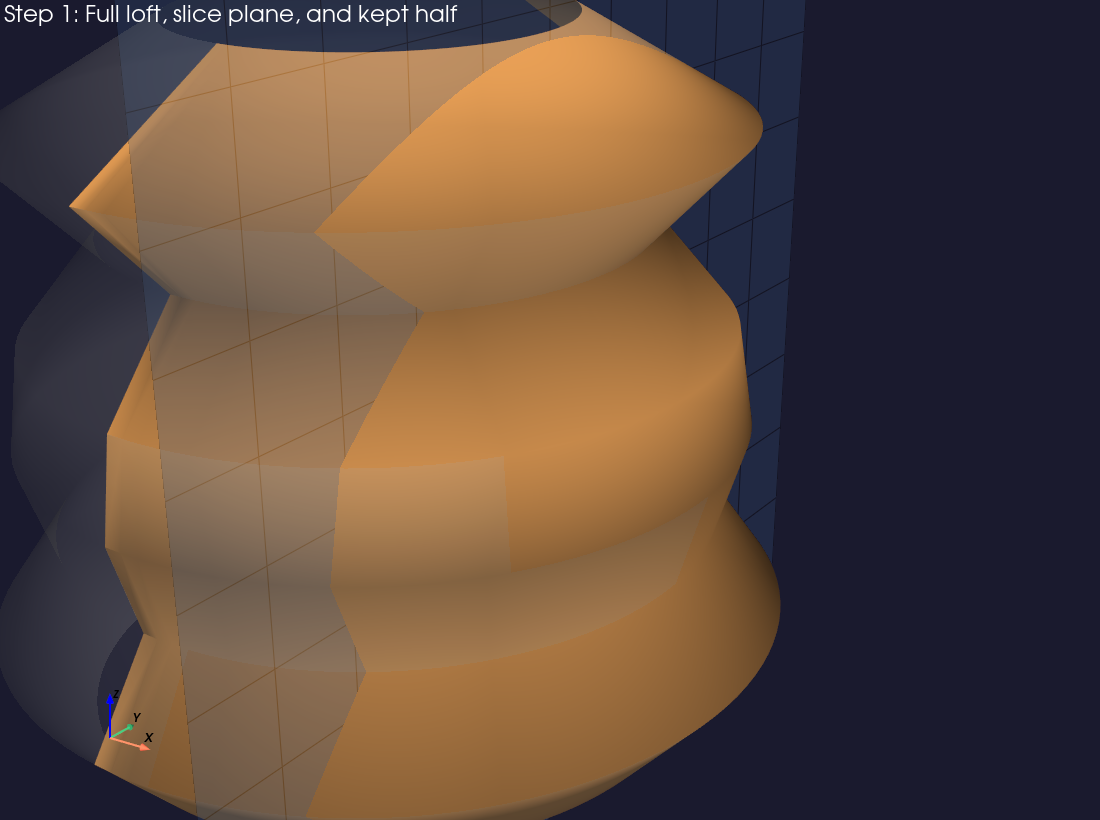

In [56]:
plane_size = 1.15 * max(
    full_surface.bounds[1] - full_surface.bounds[0],
    full_surface.bounds[3] - full_surface.bounds[2],
    full_surface.bounds[5] - full_surface.bounds[4],
)
slice_plane = pv.Plane(
    center=half_surface.center,
    direction=active_surface_config.slice_normal,
    i_size=plane_size,
    j_size=plane_size,
)

show_step(
    "Step 1: Loft the circles and clip the shape in half",
    "The eight circular sections are connected into one lofted skin. The blue plane is the YZ slicing plane at x = 0, and the solid orange surface is the kept half. This clip removes the mirrored side so the later Voronoi intersections are easier to interpret and do not duplicate across both halves.",
)
display_static_scene(
    title="Step 1: Full loft, slice plane, and kept half",
    bounds=full_surface.bounds,
    target=half_surface.center,
    meshes=[
        (
            full_surface,
            {
                "color": "#d9d9d9",
                "opacity": 0.18,
                "smooth_shading": True,
            },
        ),
        (
            slice_plane,
            {
                "color": "#6aa9ff",
                "opacity": 0.25,
                "show_edges": True,
            },
        ),
        (
            half_surface,
            {
                "color": "#ffb366",
                "opacity": 1.0,
                "smooth_shading": True,
            },
        ),
    ],
)


### Step 2: Seed the padded box for the bounded Voronoi construction

The cyan box is slightly larger than the kept loft half, and the yellow points are the random Voronoi seeds inside it. The padding matters because an unconstrained 3D Voronoi diagram would create infinite cells; this box forces every cell to stay finite before we intersect it with the loft.

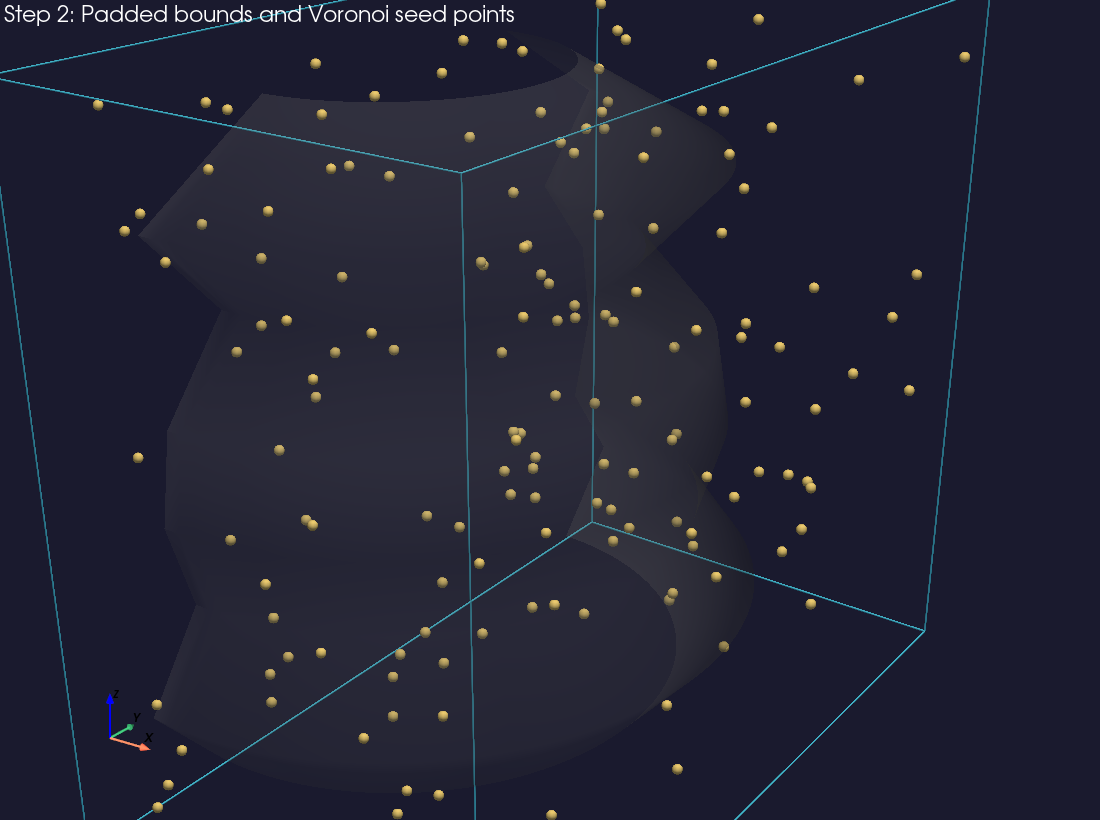

In [57]:
padded_box_edges = pv.Box(bounds=padded_bounds).extract_all_edges()

show_step(
    "Step 2: Seed the padded box for the bounded Voronoi construction",
    "The cyan box is slightly larger than the kept loft half, and the yellow points are the random Voronoi seeds inside it. The padding matters because an unconstrained 3D Voronoi diagram would create infinite cells; this box forces every cell to stay finite before we intersect it with the loft.",
)
display_static_scene(
    title="Step 2: Padded bounds and Voronoi seed points",
    bounds=padded_bounds,
    target=half_surface.center,
    meshes=[
        (
            half_surface,
            {
                "color": "#8c8c8c",
                "opacity": 0.22,
                "smooth_shading": True,
            },
        ),
    ],
    line_meshes=[
        (
            padded_box_edges,
            {
                "color": "#4dd7ff",
                "line_width": 2,
                "opacity": 0.95,
            },
        ),
    ],
    point_sets=[
        (
            seed_points,
            {
                "color": "#ffe082",
                "point_size": 11,
                "render_points_as_spheres": True,
                "opacity": 1.0,
            },
        ),
    ],
)


### Step 3: View every rebuilt intersection polyline as a separate colored trace

Each colored polyline is rebuilt from the detected discontinuity points of one retained intersection curve. Close vertices from neighboring cells are snapped together before anything downstream uses these polylines, which helps the later surface mesh stay closed without tiny breaks.

Raw intersection loops: 107
Retained intersection loops after neighbor filter: 100
Rebuilt line polylines used downstream: 89
Discarded isolated loops: 7


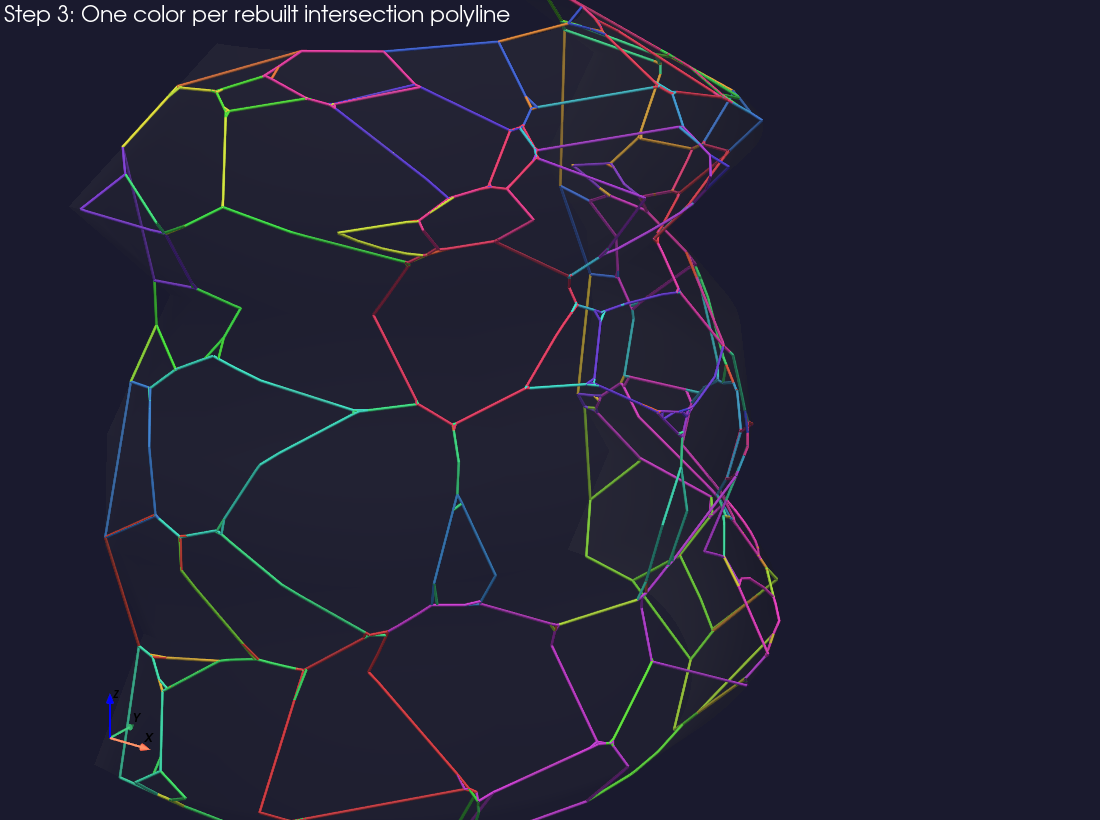

### Step 3A: Interactive inspection of the rebuilt intersection polylines

This opens the rebuilt and snapped intersection polylines in a native PyVista window so you can orbit, pan, and zoom around the clipped loft while checking how the downstream working curves sit on the surface.

In [58]:
show_step(
    "Step 3: View every rebuilt intersection polyline as a separate colored trace",
    "Each colored polyline is rebuilt from the detected discontinuity points of one retained intersection curve. Close vertices from neighboring cells are snapped together before anything downstream uses these polylines, which helps the later surface mesh stay closed without tiny breaks.",
)
print(f"Raw intersection loops: {len(raw_closed_polylines)}")
print(f"Retained intersection loops after neighbor filter: {retained_intersection_polyline_count}")
print(f"Rebuilt line polylines used downstream: {len(analysis_original_polylines)}")
print(f"Discarded isolated loops: {len(discarded_polyline_indices)}")
display_static_scene(
    title="Step 3: One color per rebuilt intersection polyline",
    bounds=half_surface.bounds,
    target=half_surface.center,
    meshes=[
        (
            half_surface,
            {
                "color": "#727272",
                "opacity": 0.13,
                "smooth_shading": True,
            },
        ),
    ],
    line_meshes=[
        (
            build_polyline_mesh([polyline]),
            {
                "color": curve_colors[index],
                "line_width": 3,
                "opacity": 1.0,
            },
        )
        for index, polyline in enumerate(analysis_original_polylines)
    ],
)
show_step(
    "Step 3A: Interactive inspection of the rebuilt intersection polylines",
    "This opens the rebuilt and snapped intersection polylines in a native PyVista window so you can orbit, pan, and zoom around the clipped loft while checking how the downstream working curves sit on the surface.",
)
display_interactive_scene(
    title="Step 3A: Interactive rebuilt intersection polylines",
    bounds=half_surface.bounds,
    target=half_surface.center,
    meshes=[
        (
            half_surface,
            {
                "color": "#727272",
                "opacity": 0.13,
                "smooth_shading": True,
            },
        ),
    ],
    line_meshes=[
        (
            build_polyline_mesh([polyline]),
            {
                "color": curve_colors[index],
                "line_width": 3,
                "opacity": 1.0,
            },
        )
        for index, polyline in enumerate(analysis_original_polylines)
    ],
    zoom_factor=1.15,
    window_size=(1300, 950),
)


In [59]:
show_step(
    "Step 4B: Interactive cell inspector (curve / surface / naked edges)",
    "Pick any cell by index. Three interactive windows open side by side: the polyline curve, the output surface mesh, and its naked boundary edges. All three are rotatable and zoomable. The cell label stays visible in each window title.",
)

cell_inspector_slider_row, cell_inspector_slider, _ = make_int_control(
    value=1,
    min_value=1,
    max_value=len(analysis_followup_polylines),
    step=1,
    description="Cell",
    slider_width="340px",
    input_width="90px",
)
cell_inspector_show_all = widgets.Checkbox(
    value=False,
    description="Show all cells from 0 to selected",
)
cell_inspector_summary = widgets.HTML()
cell_inspector_report = widgets.HTML(layout=widgets.Layout(max_height="280px", overflow="auto"))
cell_inspector_open = widgets.Button(
    description="Open interactive cell views",
    button_style="success",
)
cell_inspector_output = widgets.Output()

from compass_web.lofted_surface_voronoi import _fit_plane


def _cell_inspector_indices() -> list[int]:
    val = int(cell_inspector_slider.value)
    if val <= 0:
        return []
    if cell_inspector_show_all.value:
        return list(range(min(val, len(analysis_followup_polylines))))
    return [min(val, len(analysis_followup_polylines)) - 1]


def _cell_diagnostic(idx: int) -> dict:
    from collections import defaultdict as _dd
    a = curve_result.analyses[idx]
    mesh = analysis_output_meshes[idx]
    mode = analysis_output_modes[idx]
    if mesh.n_cells == 0:
        return {"idx": idx, "mode": mode, "empty": True}
    surf = extract_surface_mesh(mesh)
    pts = np.asarray(surf.points, dtype=float)
    fraw = np.asarray(surf.faces, dtype=int)
    fv = []
    c = 0
    while c < len(fraw):
        n = int(fraw[c])
        if n == 3:
            fv.append((int(fraw[c+1]), int(fraw[c+2]), int(fraw[c+3])))
        c += n + 1
    norms = []
    areas = []
    for aa, bb, cc in fv:
        e1 = pts[bb] - pts[aa]; e2 = pts[cc] - pts[aa]; nn = np.cross(e1, e2)
        nl = float(np.linalg.norm(nn))
        norms.append(nn / nl if nl > 1e-12 else np.zeros(3))
        areas.append(float(nl) * 0.5)
    etf = _dd(list)
    for fi, (aa, bb, cc) in enumerate(fv):
        for e in [(min(aa,bb),max(aa,bb)),(min(bb,cc),max(bb,cc)),(min(aa,cc),max(aa,cc))]:
            etf[e].append(fi)
    be = sum(1 for fis in etf.values() if len(fis) == 1)
    me = sum(1 for fis in etf.values() if len(fis) == 2)
    nm = sum(1 for fis in etf.values() if len(fis) > 2)
    bad = sum(1 for e, fis in etf.items() if len(fis) == 2 and float(np.dot(norms[fis[0]], norms[fis[1]])) < 0)
    dp = a.discontinuity_points
    if len(dp) >= 3:
        _, pu, pv_vec, pn = _fit_plane(dp)
        centered = dp - dp.mean(axis=0)
        oop = float(np.abs(centered @ pn).max())
        u_p = centered @ pu; v_p = centered @ pv_vec
        ips = float(np.sqrt((u_p.max()-u_p.min())**2 + (v_p.max()-v_p.min())**2))
        pr = oop / max(ips, 1e-9)
        ctr = a.circle_center; cd = dp - ctr
        ang = np.degrees(np.arctan2(cd @ pv_vec, cd @ pu))
        sa = np.sort(ang)
        gaps = np.diff(sa)
        wg = 360 - (sa[-1] - sa[0]) if len(sa) > 1 else 360.0
        mg = float(max(np.max(gaps), wg)) if len(gaps) > 0 else 360.0
    else:
        pr = 0.0; ips = 0.0; mg = 360.0
    return {
        "idx": idx, "mode": mode, "empty": False,
        "disc_pts": len(dp), "faces": surf.n_cells,
        "total_area": sum(areas), "boundary_edges": be,
        "manifold_edges": me, "nm_edges": nm,
        "bad_normals": bad, "planarity_ratio": pr,
        "max_angular_gap": mg, "bbox_volume": float(a.bbox_volume),
        "curve_length": float(a.curve_length),
        "circle_radius": float(a.circle_radius),
        "ratio": float(a.ratio),
        "extrusion_len": float(np.linalg.norm(a.extrusion_base_vector)),
    }


def update_cell_inspector_summary(*_: object) -> None:
    indices = _cell_inspector_indices()
    if not indices:
        cell_inspector_summary.value = "<b>No cell selected.</b>"
        cell_inspector_report.value = ""
        return
    diags = [_cell_diagnostic(idx) for idx in indices]
    issues = [d for d in diags if not d.get("empty") and d["bad_normals"] > 0]
    healthy = [d for d in diags if not d.get("empty") and d["bad_normals"] == 0]
    cell_inspector_summary.value = (
        f"<b>Showing {len(indices)} cell(s)</b>"
        f" | <span style='color:#ff5c5c'><b>{len(issues)} with normal issues</b></span>"
        f" | <span style='color:#4caf50'><b>{len(healthy)} healthy</b></span>"
    )
    rows = []
    for d in diags:
        if d.get("empty"):
            rows.append(f"<tr style='color:#888'><td>{d['idx']}</td><td>{d['mode']}</td><td colspan='12'>empty</td></tr>")
            continue
        color = "#ff5c5c" if d["bad_normals"] > 0 else "#ccc"
        rows.append(
            f"<tr style='color:{color}'>"
            f"<td><b>{d['idx']}</b></td>"
            f"<td>{d['mode']}</td>"
            f"<td>{d['disc_pts']}</td>"
            f"<td>{d['faces']}</td>"
            f"<td>{d['boundary_edges']}</td>"
            f"<td>{d['manifold_edges']}</td>"
            f"<td>{d['nm_edges']}</td>"
            f"<td><b>{d['bad_normals']}</b></td>"
            f"<td>{d['planarity_ratio']:.4f}</td>"
            f"<td>{d['max_angular_gap']:.0f}</td>"
            f"<td>{d['total_area']:.1f}</td>"
            f"<td>{d['bbox_volume']:.2f}</td>"
            f"<td>{d['curve_length']:.1f}</td>"
            f"<td>{d['ratio']:.3f}</td>"
            f"</tr>"
        )
    header = (
        "<tr style='color:#aaa;font-size:11px'>"
        "<th>ID</th><th>Class</th><th>Disc</th><th>Faces</th>"
        "<th>BE</th><th>ME</th><th>NM</th><th>BadN</th>"
        "<th>Planarity</th><th>Gap</th><th>Area</th>"
        "<th>BBoxVol</th><th>CrvLen</th><th>Ratio</th>"
        "</tr>"
    )
    cell_inspector_report.value = f"<table style='font-size:12px;border-collapse:collapse'>{header}{''.join(rows)}</table>"


for _w in [cell_inspector_slider, cell_inspector_show_all]:
    _w.observe(update_cell_inspector_summary, names="value")
update_cell_inspector_summary()


def open_cell_inspector_views(_: widgets.Button) -> None:
    indices = _cell_inspector_indices()
    if not indices:
        return

    all_polylines = []
    all_surfaces = []
    all_be_meshes = []
    all_nm_meshes = []
    all_disc_points = []
    bounds_candidates = []

    for idx in indices:
        polyline = analysis_followup_polylines[idx]
        mesh = analysis_output_meshes[idx]
        surf = extract_surface_mesh(mesh) if mesh.n_cells > 0 else pv.PolyData()
        surf = unify_mesh_normals(surf) if surf.n_cells > 0 else pv.PolyData()
        be = surf.extract_feature_edges(boundary_edges=True, feature_edges=False, manifold_edges=False, non_manifold_edges=False).clean() if surf.n_cells > 0 else pv.PolyData()
        nm = surf.extract_feature_edges(boundary_edges=False, feature_edges=False, manifold_edges=False, non_manifold_edges=True).clean() if surf.n_cells > 0 else pv.PolyData()
        all_polylines.append((idx, polyline))
        all_surfaces.append((idx, surf))
        all_be_meshes.append((idx, be))
        all_nm_meshes.append((idx, nm))
        if len(discontinuity_point_sets[idx]) > 0:
            all_disc_points.append((idx, discontinuity_point_sets[idx]))
        if mesh.n_points > 0:
            bounds_candidates.append(mesh.bounds)
        if len(polyline) > 0:
            pm = build_polyline_mesh([polyline])
            if pm.n_points > 0:
                bounds_candidates.append(pm.bounds)

    if not bounds_candidates:
        bounds_candidates.append(half_surface.bounds)
    view_bounds = padded_scene_bounds(merge_bounds(bounds_candidates), padding_fraction=0.12, min_padding=0.5)
    view_target = center_from_bounds(view_bounds)

    n_cells_shown = len(indices)
    last = indices[-1]
    title_tag = f"Cell {last} ({curve_labels[last]})" if n_cells_shown == 1 else f"Cells 0..{last} ({n_cells_shown} cells)"

    with cell_inspector_output:
        cell_inspector_output.clear_output(wait=True)
        display(Markdown(f"Opening three interactive views for **{title_tag}**."))

    plotter = pv.Plotter(
        notebook=False,
        shape=(1, 3),
        window_size=(1800, 700),
        title=title_tag,
    )
    plotter.set_background("#1a1a2e")

    plotter.subplot(0, 0)
    plotter.add_text(f"Curves: {title_tag}", font_size=11)
    plotter.add_mesh(half_surface, color="#727272", opacity=0.08, smooth_shading=True)
    for idx, polyline in all_polylines:
        if len(polyline) > 0:
            plotter.add_mesh(build_polyline_mesh([polyline]), color=curve_colors[idx], line_width=3 if n_cells_shown > 1 else 4, opacity=1.0)
    for idx, pts in all_disc_points:
        plotter.add_points(pts, color="#ff4d4d", point_size=8 if n_cells_shown > 1 else 10, render_points_as_spheres=True)
    plotter.camera_position = camera_position_from_bounds(view_bounds, view_target)
    plotter.camera.zoom(1.2)
    plotter.add_axes()

    plotter.subplot(0, 1)
    total_faces = sum(s.n_cells for _, s in all_surfaces)
    plotter.add_text(f"Surfaces: {title_tag} ({total_faces} faces)", font_size=11)
    plotter.add_mesh(half_surface, color="#727272", opacity=0.08, smooth_shading=True)
    label_points_list = []
    label_texts_list = []
    for idx, surf in all_surfaces:
        if surf.n_cells > 0:
            plotter.add_mesh(surf, color=curve_colors[idx], opacity=1.0, smooth_shading=True, show_edges=True, edge_color="#333333")
            label_points_list.append(np.asarray(surf.center, dtype=float))
            label_texts_list.append(str(idx))
    if label_points_list:
        label_pts_array = np.array(label_points_list, dtype=float)
        plotter.add_point_labels(
            label_pts_array,
            label_texts_list,
            shape_opacity=0.35,
            fill_shape=True,
            font_size=18,
            text_color="white",
            point_color="#ffe082",
            margin=5,
            show_points=True,
            point_size=8,
            always_visible=True,
        )
    plotter.camera_position = camera_position_from_bounds(view_bounds, view_target)
    plotter.camera.zoom(1.2)
    plotter.add_axes()

    plotter.subplot(0, 2)
    total_be = sum(b.n_cells for _, b in all_be_meshes)
    total_nm = sum(n.n_cells for _, n in all_nm_meshes)
    plotter.add_text(f"Naked edges: {title_tag} ({total_be} boundary, {total_nm} nm)", font_size=11)
    plotter.add_mesh(half_surface, color="#727272", opacity=0.08, smooth_shading=True)
    for idx, surf in all_surfaces:
        if surf.n_cells > 0:
            plotter.add_mesh(surf, color=curve_colors[idx], opacity=0.15, smooth_shading=True)
    for idx, be in all_be_meshes:
        if be.n_cells > 0:
            plotter.add_mesh(be, color="#00e5ff", line_width=4 if n_cells_shown > 1 else 5, opacity=1.0)
    for idx, nm in all_nm_meshes:
        if nm.n_cells > 0:
            plotter.add_mesh(nm, color="#ff3b30", line_width=3 if n_cells_shown > 1 else 4, opacity=0.9)
    plotter.camera_position = camera_position_from_bounds(view_bounds, view_target)
    plotter.camera.zoom(1.2)
    plotter.add_axes()

    plotter.link_views()
    plotter.show()


cell_inspector_open.on_click(open_cell_inspector_views)
display(
    widgets.VBox([
        cell_inspector_slider_row,
        cell_inspector_show_all,
        cell_inspector_summary,
        cell_inspector_report,
        cell_inspector_open,
        cell_inspector_output,
    ])
)

### Step 4B: Interactive cell inspector (curve / surface / naked edges)

Pick any cell by index. Three interactive windows open side by side: the polyline curve, the output surface mesh, and its naked boundary edges. All three are rotatable and zoomable. The cell label stays visible in each window title.

### Step 5: Build per-cell solids

Each cell patch is individually scaled (same center, non-uniform XY), its open edges lofted to form walls. Boundary cells (touching x=0) use multi-pass vertex propagation: faces with >=2 vertices near x=0 are offset by -2 units; each pass expands the near-plane vertex set within an interference limit so neighbouring near-plane faces are captured too. Walls are lofted between body and offset boundaries. Each cell is closed into a watertight solid. Small degenerate cells (area < 5 or < 6 faces) are removed.

Cell patches kept: 89, removed (no edges): 0
Removed (small area/faces): 0
Removed (disconnected): 0
Cell solids closed: 89/89
Total assembly faces: 16642


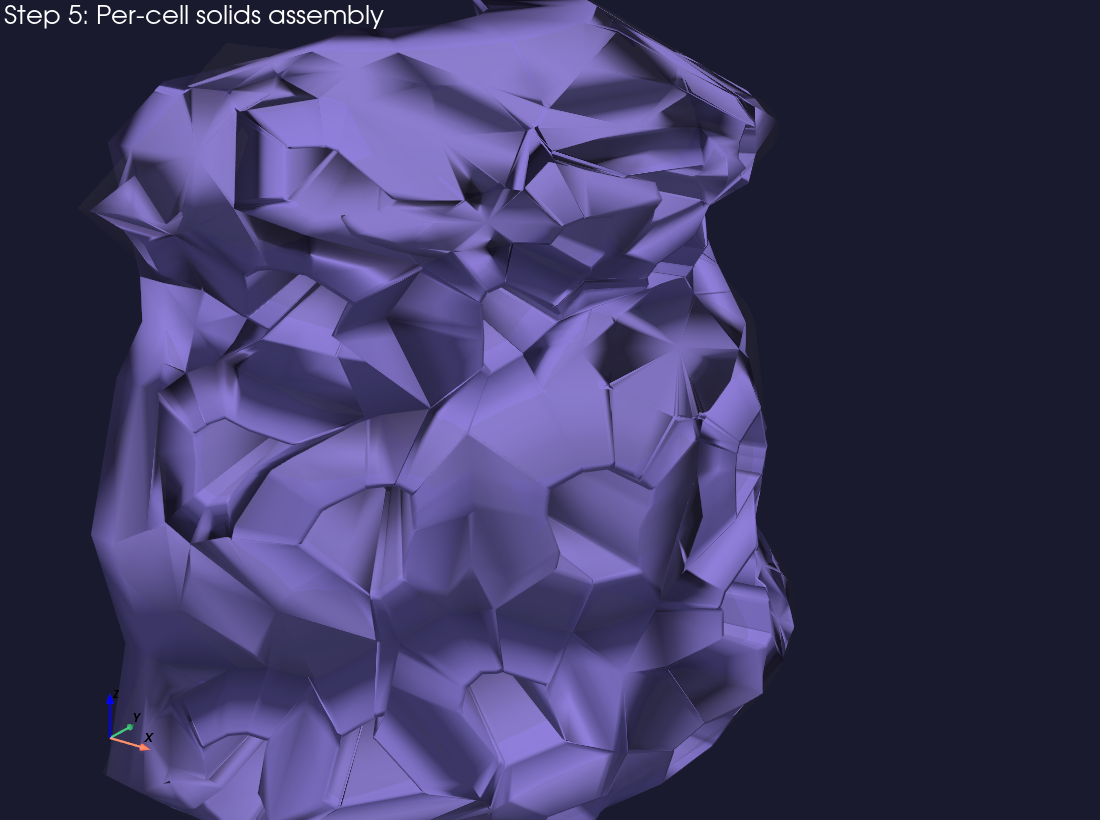

In [60]:
from compass_web.pipeline import _build_cell_solids

mesh_cleanup = clean_meshes_without_naked_edges(
    analysis_output_meshes,
    tolerance=active_surface_config.line_tolerance,
)
cell_patches = list(mesh_cleanup.kept_meshes)
removed_output_mesh_indices = list(mesh_cleanup.removed_indices)
kept_polylines_for_solids = [closed_polylines[i] for i in mesh_cleanup.kept_indices]

# Build watertight solids using the pipeline's _build_cell_solids which handles
# edge cells via polyline-level vertex detection at the cutting plane.
cell_solids = _build_cell_solids(
    cell_patches,
    loft_bbox_center=initial_loft_bbox_center,
    scale_x=scale_x,
    scale_y=scale_y,
    slice_normal=active_surface_config.slice_normal,
    slice_origin=active_surface_config.slice_origin,
    tolerance=active_surface_config.line_tolerance,
)
cell_solid_reports: list[dict] = []
for ci, solid in enumerate(cell_solids):
    r = build_mesh_printability_report(solid, tolerance=active_surface_config.line_tolerance)
    cell_solid_reports.append({"idx": ci, "faces": solid.n_cells, "closed": r.is_closed, "be": r.boundary_edge_count})

# Filter: remove disconnected cells (not in the largest connected region)
test_assembly = _merge_meshes([s for s in cell_solids if s.n_cells > 0])
n_regions = count_connected_regions(test_assembly)
if n_regions > 1:
    conn = test_assembly.connectivity()
    region_ids = np.asarray(conn["RegionId"], dtype=int)
    from collections import Counter as _Counter
    region_sizes = _Counter(region_ids)
    largest_rid = max(region_sizes, key=region_sizes.get)
    face_offset = 0
    keep_mask = []
    for ci, solid in enumerate(cell_solids):
        if solid.n_cells == 0:
            keep_mask.append(False)
            continue
        mid = face_offset + solid.n_cells // 2
        in_main = int(region_ids[mid]) == largest_rid if mid < len(region_ids) else False
        keep_mask.append(in_main)
        face_offset += solid.n_cells
    removed_disconnected = sum(1 for k in keep_mask if not k)
    cell_solids = [s for s, k in zip(cell_solids, keep_mask) if k]
    cell_solid_reports = [r for r, k in zip(cell_solid_reports, keep_mask) if k]
else:
    removed_disconnected = 0

closed_count = sum(1 for r in cell_solid_reports if r["closed"])
generated_surface = _merge_meshes([s for s in cell_solids if s.n_cells > 0])

generated_bounds = generated_surface.bounds if generated_surface.n_points else half_surface.bounds
generated_target = generated_surface.center if generated_surface.n_points else half_surface.center

show_step(
    "Step 5: Build per-cell solids",
    "Each cell patch is individually scaled (same center, non-uniform XY), its open edges lofted to form walls. "
    "Boundary cells (touching x=0) use multi-pass vertex propagation: faces with >=2 vertices near x=0 are "
    "offset by -2 units; each pass expands the near-plane vertex set within an interference limit so "
    "neighbouring near-plane faces are captured too. Walls are lofted between body and offset boundaries. "
    "Each cell is closed into a watertight solid. Small degenerate cells (area < 5 or < 6 faces) are removed.",
)
print(f"Cell patches kept: {len(cell_patches)}, removed (no edges): {len(removed_output_mesh_indices)}")
print(f"Removed (small area/faces): {len(cell_patches) - len(cell_solids) - removed_disconnected}")
print(f"Removed (disconnected): {removed_disconnected}")
print(f"Cell solids closed: {closed_count}/{len(cell_solids)}")
print(f"Total assembly faces: {generated_surface.n_cells}")
display_static_scene(
    title="Step 5: Per-cell solids assembly",
    bounds=generated_bounds,
    target=generated_target,
    meshes=[
        (half_surface, {"color": "#808080", "opacity": 0.1, "smooth_shading": True}),
        (generated_surface, {"color": "#9b8cff", "opacity": 1.0, "smooth_shading": True}),
    ],
)
display_interactive_scene(
    title="Step 5A: Interactive per-cell solids assembly",
    bounds=generated_bounds,
    target=generated_target,
    meshes=[
        (half_surface, {"color": "#808080", "opacity": 0.08, "smooth_shading": True}),
        (generated_surface, {"color": "#9b8cff", "opacity": 1.0, "smooth_shading": True}),
    ],
    zoom_factor=1.2,
    window_size=(1300, 950),
)


In [61]:
show_step(
    "Step 5B: Per-cell solid inspector",
    "Use the slider to pick a cell. With the checkbox off, you see that single cell solid. With it on, you see all solids from 0 up to the selected index. Click the button to open an interactive view.",
)

cell_solid_slider_row, cell_solid_slider, _ = make_int_control(
    value=1, min_value=1, max_value=len(cell_solids),
    step=1, description="Cell", slider_width="340px", input_width="90px",
)
cell_solid_show_all = widgets.Checkbox(value=False, description="Show all up to selected")
cell_solid_summary = widgets.HTML()
cell_solid_open = widgets.Button(description="Open interactive view", button_style="success")
cell_solid_output = widgets.Output()


def _cell_solid_indices() -> list[int]:
    val = int(cell_solid_slider.value)
    if val <= 0:
        return []
    if cell_solid_show_all.value:
        return list(range(min(val, len(cell_solids))))
    return [min(val, len(cell_solids)) - 1]


def _update_cell_solid_summary(*_: object) -> None:
    indices = _cell_solid_indices()
    if not indices:
        cell_solid_summary.value = "<b>No cell selected.</b>"
        return
    total_f = sum(cell_solids[i].n_cells for i in indices)
    closed_n = sum(1 for i in indices if cell_solid_reports[i]["closed"])
    if len(indices) == 1:
        idx = indices[0]
        rpt = cell_solid_reports[idx]
        cell_solid_summary.value = (
            f"<b>Cell {idx}</b>"
            f" | Faces: {rpt['faces']}"
            f" | Closed: {rpt['closed']}"
            f" | BE: {rpt['be']}"
        )
    else:
        cell_solid_summary.value = (
            f"<b>Cells 0..{indices[-1]}</b> ({len(indices)} cells)"
            f" | Total faces: {total_f}"
            f" | Closed: {closed_n}/{len(indices)}"
        )


for _w in [cell_solid_slider, cell_solid_show_all]:
    _w.observe(_update_cell_solid_summary, names="value")
_update_cell_solid_summary()


def _open_cell_solid_view(_: widgets.Button) -> None:
    indices = _cell_solid_indices()
    if not indices:
        return
    n = len(indices)

    if n == 1:
        idx = indices[0]
        title = f"Cell {idx} debug"
        solid = cell_solids[idx]
        color = curve_colors[mesh_cleanup.kept_indices[idx]] if idx < len(mesh_cleanup.kept_indices) else "#9b8cff"

        raw_mesh = extract_surface_mesh(cell_patches[idx])
        raw_scaled = scale_polydata_in_xy(raw_mesh, center=initial_loft_bbox_center, scale_x=scale_x, scale_y=scale_y)
        _, raw_loops = extract_naked_edge_loops(raw_mesh, tolerance=active_surface_config.line_tolerance)
        raw_scaled_loops = [scale_points_in_xy(l, center=initial_loft_bbox_center, scale_x=scale_x, scale_y=scale_y) for l in raw_loops]
        raw_lofts = [_loft_between_polylines(s, t) for s, t in zip(raw_loops, raw_scaled_loops) if len(s) >= 2 and len(t) >= 2]
        raw_solid = _merge_meshes([p for p in [raw_mesh, raw_scaled] + raw_lofts if p.n_cells > 0])

        body_patch, moved_patch = split_and_offset_plane_faces(
            raw_solid, plane_normal=active_surface_config.slice_normal,
            plane_origin=active_surface_config.slice_origin, offset_amount=-2.0,
            tolerance=active_surface_config.line_tolerance,
        )

        if moved_patch.n_cells == 0:
            _pa = int(np.argmax(np.abs(active_surface_config.slice_normal)))
            _pc = float(active_surface_config.slice_origin[_pa])
            _pl = _extract_plane_edge_loops(raw_solid, _pa, _pc, active_surface_config.line_tolerance)
            if _pl:
                from compass_web.pipeline import _build_cap_from_loop
                _ocaps = []
                for _loop in _pl:
                    _cap = _build_cap_from_loop(_loop, active_surface_config.line_tolerance)
                    if _cap.n_cells > 0:
                        _op = np.asarray(_cap.points, dtype=float).copy()
                        _op[:, _pa] += -2.0
                        _oc = _cap.copy()
                        _oc.points = _op
                        _ocaps.append(_oc)
                if _ocaps:
                    body_patch = raw_solid
                    moved_patch = _merge_meshes([c for c in _ocaps if c.n_cells > 0])

        _, body_loops = extract_naked_edge_loops(body_patch, tolerance=active_surface_config.line_tolerance) if body_patch.n_cells > 0 else (None, [])
        _, moved_loops = extract_naked_edge_loops(moved_patch, tolerance=active_surface_config.line_tolerance) if moved_patch.n_cells > 0 else (None, [])
        body_edge_mesh = build_polyline_mesh(body_loops)
        moved_edge_mesh = build_polyline_mesh(moved_loops)

        n_plane_faces = moved_patch.n_cells
        n_body_loops = len(body_loops) if body_loops else 0
        n_moved_loops = len(moved_loops) if moved_loops else 0

        bounds_list = [s.bounds for s in [solid, body_patch, moved_patch] if s.n_cells > 0]
        if not bounds_list:
            bounds_list = [half_surface.bounds]
        vb = padded_scene_bounds(merge_bounds(bounds_list), padding_fraction=0.15, min_padding=0.5)
        vt = center_from_bounds(vb)

        with cell_solid_output:
            cell_solid_output.clear_output(wait=True)
            display(Markdown(
                f"**Cell {idx}**: plane_faces={n_plane_faces}, "
                f"body_loops={n_body_loops}, moved_loops={n_moved_loops}"
            ))

        ncols = 4 if moved_patch.n_cells > 0 else 2
        plotter = pv.Plotter(notebook=False, shape=(1, ncols), window_size=(ncols * 450, 700), title=title)
        plotter.set_background("#1a1a2e")

        plotter.subplot(0, 0)
        plotter.add_text(f"Raw solid (before split)", font_size=10)
        plotter.add_mesh(raw_solid, color=color, opacity=1.0, smooth_shading=True, show_edges=True, edge_color="#333333")
        plotter.camera_position = camera_position_from_bounds(vb, vt)
        plotter.camera.zoom(1.2)
        plotter.add_axes()

        plotter.subplot(0, 1)
        plotter.add_text(f"Final solid ({solid.n_cells}f)", font_size=10)
        plotter.add_mesh(solid, color=color, opacity=1.0, smooth_shading=True, show_edges=True, edge_color="#333333")
        plotter.camera_position = camera_position_from_bounds(vb, vt)
        plotter.camera.zoom(1.2)
        plotter.add_axes()

        if ncols == 4:
            plotter.subplot(0, 2)
            plotter.add_text(f"Body ({body_patch.n_cells}f) + Moved ({moved_patch.n_cells}f)", font_size=10)
            if body_patch.n_cells > 0:
                plotter.add_mesh(body_patch, color="#72b7ff", opacity=0.7, smooth_shading=True)
            if moved_patch.n_cells > 0:
                plotter.add_mesh(moved_patch, color="#ff9f43", opacity=0.9, smooth_shading=True)
            plotter.camera_position = camera_position_from_bounds(vb, vt)
            plotter.camera.zoom(1.2)
            plotter.add_axes()

            plotter.subplot(0, 3)
            plotter.add_text(f"Open edges: body={len(body_loops)} moved={len(moved_loops)}", font_size=10)
            if body_patch.n_cells > 0:
                plotter.add_mesh(body_patch, color="#72b7ff", opacity=0.12, smooth_shading=True)
            if moved_patch.n_cells > 0:
                plotter.add_mesh(moved_patch, color="#ff9f43", opacity=0.12, smooth_shading=True)
            if body_edge_mesh.n_points > 0:
                plotter.add_mesh(body_edge_mesh, color="#00e5ff", line_width=5, opacity=1.0)
            if moved_edge_mesh.n_points > 0:
                plotter.add_mesh(moved_edge_mesh, color="#ff3b30", line_width=5, opacity=1.0)
            plotter.camera_position = camera_position_from_bounds(vb, vt)
            plotter.camera.zoom(1.2)
            plotter.add_axes()

        plotter.link_views()
        plotter.show()
    else:
        title = f"Cells 0..{indices[-1]} ({n})"
        bounds_list = [cell_solids[i].bounds for i in indices if cell_solids[i].n_cells > 0]
        if not bounds_list:
            bounds_list = [half_surface.bounds]
        vb = padded_scene_bounds(merge_bounds(bounds_list), padding_fraction=0.12, min_padding=0.5)
        vt = center_from_bounds(vb)
        with cell_solid_output:
            cell_solid_output.clear_output(wait=True)
            display(Markdown(f"Opening view for **{title}**."))
        plotter = pv.Plotter(notebook=False, window_size=(1400, 900), title=title)
        plotter.set_background("#1a1a2e")
        plotter.add_mesh(half_surface, color="#727272", opacity=0.06, smooth_shading=True)
        for idx in indices:
            plotter.add_mesh(cell_solids[idx], color=curve_colors[mesh_cleanup.kept_indices[idx]], opacity=1.0, smooth_shading=True)
        if n <= 30:
            lp = np.array([cell_solids[i].center for i in indices if cell_solids[i].n_cells > 0])
            lt = [str(i) for i in indices if cell_solids[i].n_cells > 0]
            if len(lp) > 0:
                plotter.add_point_labels(lp, lt, font_size=14, text_color="white", point_size=6, always_visible=True, shape_opacity=0.25)
        plotter.camera_position = camera_position_from_bounds(vb, vt)
        plotter.camera.zoom(1.3)
        plotter.add_axes()
        plotter.show()


cell_solid_open.on_click(_open_cell_solid_view)
display(widgets.VBox([
    cell_solid_slider_row,
    cell_solid_show_all,
    cell_solid_summary,
    cell_solid_open,
    cell_solid_output,
]))

### Step 5B: Per-cell solid inspector

Use the slider to pick a cell. With the checkbox off, you see that single cell solid. With it on, you see all solids from 0 up to the selected index. Click the button to open an interactive view.

In [62]:
from compass_web.pipeline import _extract_plane_edge_loops, _build_cap_from_loop

show_step(
    "Step 5C: Solid generation step-by-step debugger",
    "Pick any cell by index. Opens a native VTK window with 7 subplots showing "
    "every sub-step of the solid generation: surface patch, scaled surface, loft "
    "bands, raw merged solid with naked edges, split/offset result, wall lofts, "
    "and the final closed solid. Use this to diagnose edge cells near the cutting plane.",
)

def _debug_solid_steps(cell_idx: int) -> None:
    """Open a 7-subplot native window showing every solid-generation sub-step."""
    if cell_idx < 0 or cell_idx >= len(cell_patches):
        print(f"Cell index {cell_idx} out of range (0..{len(cell_patches)-1})")
        return

    tol_local = active_surface_config.line_tolerance
    s_normal = active_surface_config.slice_normal
    s_origin = active_surface_config.slice_origin
    plane_axis = int(np.argmax(np.abs(s_normal)))
    plane_coord = float(s_origin[plane_axis])
    offset_amount = -2.0

    patch = cell_patches[cell_idx]

    # Sub-step 1: surface patch
    surf = extract_surface_mesh(patch)

    # Sub-step 2: scaled surface
    scaled_surf = scale_polydata_in_xy(
        surf, center=initial_loft_bbox_center, scale_x=scale_x, scale_y=scale_y
    )

    # Sub-step 3: naked edge loops + loft bands
    _, open_loops = extract_naked_edge_loops(surf, tolerance=tol_local)
    scaled_loops = [
        scale_points_in_xy(l, center=initial_loft_bbox_center, scale_x=scale_x, scale_y=scale_y)
        for l in open_loops
    ]
    loft_bands = [
        _loft_between_polylines(s, t)
        for s, t in zip(open_loops, scaled_loops)
        if len(s) >= 2 and len(t) >= 2
    ]

    # Sub-step 4: raw merged solid
    raw_solid = _merge_meshes(
        [p for p in [surf, scaled_surf] + loft_bands if p.n_cells > 0]
    )
    _, raw_naked = extract_naked_edge_loops(raw_solid, tolerance=tol_local)
    raw_naked_mesh = build_polyline_mesh(raw_naked) if raw_naked else pv.PolyData()

    # Sub-step 5: split_and_offset
    body_patch, moved_patch = split_and_offset_plane_faces(
        raw_solid, plane_normal=s_normal, plane_origin=s_origin,
        offset_amount=offset_amount, tolerance=tol_local,
    )

    # Sub-step 5b: fallback cap for cells with no plane faces at all
    cap_mesh = pv.PolyData()
    offset_cap_mesh = pv.PolyData()
    if moved_patch.n_cells == 0:
        plane_loops = _extract_plane_edge_loops(raw_solid, plane_axis, plane_coord, tol_local)
        if plane_loops:
            caps = []
            ocaps = []
            for pl_loop in plane_loops:
                cap = _build_cap_from_loop(pl_loop, tol_local)
                if cap.n_cells > 0:
                    caps.append(cap)
                    op = np.asarray(cap.points, dtype=float).copy()
                    op[:, plane_axis] += offset_amount
                    oc = cap.copy()
                    oc.points = op
                    ocaps.append(oc)
            if caps:
                cap_mesh = _merge_meshes([c for c in caps if c.n_cells > 0])
                offset_cap_mesh = _merge_meshes([c for c in ocaps if c.n_cells > 0])
                body_patch = raw_solid
                moved_patch = offset_cap_mesh

    # Sub-step 6: wall lofts with distance + length check
    wall_loft_meshes: list[pv.PolyData] = []
    if moved_patch.n_cells > 0:
        _, body_loops_dbg = extract_naked_edge_loops(body_patch, tolerance=tol_local)
        _, moved_loops_dbg = extract_naked_edge_loops(moved_patch, tolerance=tol_local)
        used_dbg: set[int] = set()
        for bl in body_loops_dbg:
            bl_len = float(np.sum(np.linalg.norm(np.diff(bl, axis=0), axis=1))) if len(bl) >= 2 else 0.0
            best_mi = None
            best_d = float("inf")
            for mi, ml in enumerate(moved_loops_dbg):
                if mi in used_dbg:
                    continue
                d = float(np.linalg.norm(bl.mean(axis=0) - ml.mean(axis=0)))
                ml_len = float(np.sum(np.linalg.norm(np.diff(ml, axis=0), axis=1))) if len(ml) >= 2 else 0.0
                max_l = max(bl_len, ml_len)
                if max_l > 0 and min(bl_len, ml_len) / max_l < 0.3:
                    continue
                if d < best_d:
                    best_d = d
                    best_mi = mi
            if best_mi is not None and len(bl) >= 2:
                used_dbg.add(best_mi)
                lr = align_loops_and_loft(bl, moved_loops_dbg[best_mi], tolerance=tol_local)
                if lr.n_cells > 0:
                    wall_loft_meshes.append(lr)
    else:
        body_loops_dbg = []
        moved_loops_dbg = []

    # Sub-step 7: final solid (from the already-built cell_solids)
    final_solid = cell_solids[cell_idx] if cell_idx < len(cell_solids) else pv.PolyData()
    rep = build_mesh_printability_report(final_solid, tolerance=tol_local)

    # Gather info
    pts_raw = np.asarray(raw_solid.points, dtype=float) if raw_solid.n_points > 0 else np.zeros((0,3))
    pts_final = np.asarray(final_solid.points, dtype=float) if final_solid.n_points > 0 else np.zeros((0,3))

    _raw_pts = np.asarray(raw_solid.points, dtype=float) if raw_solid.n_points > 0 else np.zeros((0, 3))
    _is_bnd = bool(np.any(np.abs(_raw_pts[:, plane_axis] - plane_coord) < tol_local * 50)) if _raw_pts.size > 0 else False
    info_lines = [
        f"Cell {cell_idx} (boundary={_is_bnd})",
        f"Patch: {patch.n_cells}f | Surf: {surf.n_cells}f | Scaled: {scaled_surf.n_cells}f",
        f"Loops: {len(open_loops)} | Bands: {len(loft_bands)}",
        f"Raw: {raw_solid.n_cells}f naked={len(raw_naked)}",
        f"Split: body={body_patch.n_cells}f moved={moved_patch.n_cells}f (multi-pass >=2v)",
        f"Cap fallback: {cap_mesh.n_cells}f | Offset cap: {offset_cap_mesh.n_cells}f",
        f"Walls: {len(wall_loft_meshes)} lofts",
        f"Final: {final_solid.n_cells}f closed={rep.is_closed} be={rep.boundary_edge_count}",
    ]
    if pts_raw.size > 0:
        info_lines.append(f"Raw X: [{pts_raw[:,0].min():.3f}, {pts_raw[:,0].max():.3f}]")
    if pts_final.size > 0:
        info_lines.append(f"Final X: [{pts_final[:,0].min():.3f}, {pts_final[:,0].max():.3f}]")
    info_text = " | ".join(info_lines)

    # Compute view bounds from the largest mesh
    all_meshes = [m for m in [surf, scaled_surf, raw_solid, final_solid] if m.n_cells > 0]
    if all_meshes:
        vb = padded_scene_bounds(merge_bounds([m.bounds for m in all_meshes]), padding_fraction=0.15, min_padding=0.5)
    else:
        vb = padded_scene_bounds(half_surface.bounds, padding_fraction=0.15)
    vt = center_from_bounds(vb)
    cam = camera_position_from_bounds(vb, vt)

    # Build the 7-subplot window
    pl = pv.Plotter(notebook=False, shape=(2, 4), window_size=(1800, 900),
                     title=f"Solid Debug: Cell {cell_idx}")
    ghost_kw = dict(color="#444466", opacity=0.06, smooth_shading=True)

    # 1: Surface patch
    pl.subplot(0, 0)
    pl.set_background("#1a1a2e")
    pl.add_mesh(half_surface, **ghost_kw)
    pl.add_mesh(surf, color="#4488ff", opacity=1.0, smooth_shading=True, show_edges=True, edge_color="#222244")
    pl.add_text("1. Surface patch", position="upper_left", font_size=9, color="white")
    pl.add_axes(); pl.camera_position = cam

    # 2: Scaled surface
    pl.subplot(0, 1)
    pl.set_background("#1a1a2e")
    pl.add_mesh(half_surface, **ghost_kw)
    pl.add_mesh(surf, color="#4488ff", opacity=0.2, smooth_shading=True)
    pl.add_mesh(scaled_surf, color="#44cc66", opacity=1.0, smooth_shading=True, show_edges=True, edge_color="#224422")
    pl.add_text("2. Scaled surface", position="upper_left", font_size=9, color="white")
    pl.add_axes(); pl.camera_position = cam

    # 3: Loft bands
    pl.subplot(0, 2)
    pl.set_background("#1a1a2e")
    pl.add_mesh(half_surface, **ghost_kw)
    pl.add_mesh(surf, color="#4488ff", opacity=0.15, smooth_shading=True)
    pl.add_mesh(scaled_surf, color="#44cc66", opacity=0.15, smooth_shading=True)
    for band in loft_bands:
        if band.n_cells > 0:
            pl.add_mesh(band, color="#ff8833", opacity=0.9, smooth_shading=True, show_edges=True, edge_color="#442211")
    pl.add_text(f"3. Loft bands ({len(loft_bands)})", position="upper_left", font_size=9, color="white")
    pl.add_axes(); pl.camera_position = cam

    # 4: Raw solid + naked edges
    pl.subplot(0, 3)
    pl.set_background("#1a1a2e")
    pl.add_mesh(half_surface, **ghost_kw)
    pl.add_mesh(raw_solid, color="#cccccc", opacity=0.7, smooth_shading=True, show_edges=True, edge_color="#333333")
    if raw_naked_mesh.n_cells > 0:
        pl.add_mesh(raw_naked_mesh, color="#ff2222", line_width=4, render_lines_as_tubes=True)
    pl.add_text(f"4. Raw solid (naked={len(raw_naked)})", position="upper_left", font_size=9, color="white")
    pl.add_axes(); pl.camera_position = cam

    # 5: Split/offset result
    pl.subplot(1, 0)
    pl.set_background("#1a1a2e")
    pl.add_mesh(half_surface, **ghost_kw)
    if body_patch.n_cells > 0:
        pl.add_mesh(body_patch, color="#cccccc", opacity=0.6, smooth_shading=True, show_edges=True, edge_color="#333333")
    if moved_patch.n_cells > 0:
        pl.add_mesh(moved_patch, color="#ff44ff", opacity=0.9, smooth_shading=True, show_edges=True, edge_color="#440044")
    if cap_mesh.n_cells > 0:
        pl.add_mesh(cap_mesh, color="#ffff44", opacity=0.8, smooth_shading=True)
    label5 = f"5. Body={body_patch.n_cells}f + Moved={moved_patch.n_cells}f"
    if cap_mesh.n_cells > 0:
        label5 += f" (cap={cap_mesh.n_cells}f)"
    pl.add_text(label5, position="upper_left", font_size=9, color="white")
    pl.add_axes(); pl.camera_position = cam

    # 6: Wall lofts
    pl.subplot(1, 1)
    pl.set_background("#1a1a2e")
    pl.add_mesh(half_surface, **ghost_kw)
    if body_patch.n_cells > 0:
        pl.add_mesh(body_patch, color="#cccccc", opacity=0.2, smooth_shading=True)
    if moved_patch.n_cells > 0:
        pl.add_mesh(moved_patch, color="#ff44ff", opacity=0.2, smooth_shading=True)
    for wl in wall_loft_meshes:
        if wl.n_cells > 0:
            pl.add_mesh(wl, color="#ffcc22", opacity=0.9, smooth_shading=True, show_edges=True, edge_color="#443300")
    body_loop_mesh = build_polyline_mesh(body_loops_dbg) if body_loops_dbg else pv.PolyData()
    moved_loop_mesh = build_polyline_mesh(moved_loops_dbg) if moved_loops_dbg else pv.PolyData()
    if body_loop_mesh.n_cells > 0:
        pl.add_mesh(body_loop_mesh, color="#ff4444", line_width=3, render_lines_as_tubes=True)
    if moved_loop_mesh.n_cells > 0:
        pl.add_mesh(moved_loop_mesh, color="#44ff44", line_width=3, render_lines_as_tubes=True)
    pl.add_text(f"6. Wall lofts ({len(wall_loft_meshes)})", position="upper_left", font_size=9, color="white")
    pl.add_axes(); pl.camera_position = cam

    # 7: Final solid
    pl.subplot(1, 2)
    pl.set_background("#1a1a2e")
    pl.add_mesh(half_surface, **ghost_kw)
    if final_solid.n_cells > 0:
        pl.add_mesh(final_solid, color="#9b8cff", opacity=1.0, smooth_shading=True, show_edges=True, edge_color="#332255")
    closed_tag = "CLOSED" if rep.is_closed else f"OPEN be={rep.boundary_edge_count}"
    pl.add_text(f"7. Final solid ({closed_tag})", position="upper_left", font_size=9, color="white")
    pl.add_axes(); pl.camera_position = cam

    # 8: Info panel (text summary)
    pl.subplot(1, 3)
    pl.set_background("#1a1a2e")
    for li, line in enumerate(info_lines):
        y_pos = 0.95 - li * 0.09
        pl.add_text(line, position=(0.02, y_pos), font_size=9, color="white", viewport=True)

    pl.link_views()
    pl.show()


# UI: dropdown + button
_dbg_dd = widgets.Dropdown(
    options=[(f"Cell {i}", i) for i in range(len(cell_patches))],
    value=0,
    description="Cell:",
    layout=widgets.Layout(width="200px"),
)
_dbg_btn = widgets.Button(description="Open Debug View", button_style="info", layout=widgets.Layout(width="180px"))

def _on_dbg_click(_ev):
    _debug_solid_steps(_dbg_dd.value)
_dbg_btn.on_click(_on_dbg_click)

display(widgets.HBox([_dbg_dd, _dbg_btn]))

### Step 5C: Solid generation step-by-step debugger

Pick any cell by index. Opens a native VTK window with 7 subplots showing every sub-step of the solid generation: surface patch, scaled surface, loft bands, raw merged solid with naked edges, split/offset result, wall lofts, and the final closed solid. Use this to diagnose edge cells near the cutting plane.

In [63]:
show_step(
    "Step 6: Export per-cell volumes as STL",
    "Orients normals outward on each cell solid, fixes winding via trimesh, rotates so the sliced face lies flat on XY, and exports with a timestamped filename.",
)

import trimesh
from datetime import datetime


final_trimesh = build_export_trimesh(cell_solids)
volume_count = sum(
    1 for s in cell_solids
    if trimesh.Trimesh(
        vertices=np.asarray(orient_normals_outward(s).points),
        faces=np.asarray(orient_normals_outward(s).faces).reshape((-1, 4))[:, 1:] if orient_normals_outward(s).n_cells > 0 else np.zeros((0, 3), dtype=int),
        process=True,
    ).is_volume
)

print(
    f"Cell volumes: {volume_count}/{len(cell_solids)}, "
    f"combined faces: {len(final_trimesh.faces)}, "
    f"watertight: {final_trimesh.is_watertight}, "
    f"volume: {final_trimesh.is_volume}"
)

ts = datetime.now().strftime("%Y%m%d_%H%M%S")
export_dir = Path("exports")
export_dir.mkdir(parents=True, exist_ok=True)
stl_path = export_dir / f"voronoi_shell_{ts}.stl"
final_trimesh.export(str(stl_path))
print(f"STL exported to: {stl_path} ({stl_path.stat().st_size / 1024:.1f} KB)")

display_interactive_scene(
    title="Step 6: Final assembly (per-cell volumes, rotated for printing)",
    bounds=generated_bounds,
    target=generated_target,
    meshes=[
        (generated_surface, {"color": "#9b8cff", "opacity": 1.0, "smooth_shading": True}),
    ],
    zoom_factor=1.8,
    window_size=(1300, 950),
)


### Step 6: Export per-cell volumes as STL

Orients normals outward on each cell solid, fixes winding via trimesh, rotates so the sliced face lies flat on XY, and exports with a timestamped filename.

Cell volumes: 3/89, combined faces: 16642, watertight: True, volume: True
STL exported to: exports\voronoi_shell_20260409_013942.stl (812.7 KB)


In [48]:
show_step(
    "Step 7: Auto-retry with different seeds",
    "If the exported mesh is not a valid volume, this cell automatically retries the full pipeline with different voronoi seeds (up to 10 attempts). Only the seed changes; all other parameters stay the same.",
)


if not final_trimesh.is_volume:
    print("Mesh is not a valid volume. Starting auto-retry with different seeds...")
    pipeline_cfg = PipelineConfig(
        radii=active_surface_config.radii,
        z_increment=active_surface_config.z_increment,
        seed_count=active_point_config.seed_count,
        random_seed=active_point_config.random_seed,
        extrusion_multiplier=raw_extrusion_multiplier,
        scale_x=scale_x,
        scale_y=scale_y,
        circle_resolution=active_surface_config.circle_resolution,
        bbox_padding=active_surface_config.bbox_padding,
        line_tolerance=active_surface_config.line_tolerance,
    )
    retry_result, retry_cfg = run_pipeline_with_retry(pipeline_cfg, max_attempts=10, verbose=True)
    if retry_result.is_valid_volume:
        ts_retry = datetime.now().strftime("%Y%m%d_%H%M%S")
        retry_path = export_dir / f"voronoi_shell_{ts_retry}_seed{retry_cfg.random_seed}.stl"
        retry_result.trimesh_result.export(str(retry_path))
        print(f"SUCCESS: exported to {retry_path}")
    else:
        print("All attempts failed. Try adjusting other parameters.")
else:
    print("Mesh is already a valid volume. No retry needed.")

### Step 7: Auto-retry with different seeds

If the exported mesh is not a valid volume, this cell automatically retries the full pipeline with different voronoi seeds (up to 10 attempts). Only the seed changes; all other parameters stay the same.

Mesh is already a valid volume. No retry needed.
